In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("habeebanmemon/fakenewsnet-dataset")

print("Path to dataset files:", path)

100%|██████████| 952M/952M [00:08<00:00, 125MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/habeebanmemon/fakenewsnet-dataset/versions/1


## Loading Data from Kaggle API, Size is 10.69 GB.

In [2]:
import os

# List all files and directories in the downloaded path
files_in_dataset = os.listdir(path)
print(files_in_dataset)

['FakeNewsNet_Dataset']


In [3]:
import os

fakenewsnet_dataset_path = os.path.join(path, 'FakeNewsNet_Dataset')
files_in_fakenewsnet_dataset = os.listdir(fakenewsnet_dataset_path)
print(files_in_fakenewsnet_dataset)

['politifact_real', 'gossipcop_real', 'gossipcop_fake', 'politifact_fake']


In [4]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import re # For text cleaning
from collections import Counter # For word frequency
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize

# Ensure NLTK resources are downloaded
try:
    nltk.data.find('corpora/stopwords')
except LookupError: # Changed from nltk.downloader.DownloadError to LookupError
    nltk.download('stopwords')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError: # Changed from nltk.downloader.DownloadError to LookupError
    nltk.download('punkt')

# --- Configuration and Paths ---
# Assuming 'fakenewsnet_dataset_path' is available from previous cells
# Example: fakenewsnet_dataset_path = '/kaggle/input/fakenewsnet-dataset/FakeNewsNet_Dataset'

# Ensure the path variable is correctly defined. If not, set a default.
if 'fakenewsnet_dataset_path' not in locals():
    print("Warning: 'fakenewsnet_dataset_path' not found. Using a default placeholder.")
    print("Please ensure the path to your FakeNewsNet_Dataset folder is correctly set.")
    # This placeholder path might need adjustment based on where the user's data actually resides
    fakenewsnet_dataset_path = '/kaggle/input/fakenewsnet-dataset/FakeNewsNet_Dataset'

print(f"Using dataset root path: {fakenewsnet_dataset_path}")



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Using dataset root path: /root/.cache/kagglehub/datasets/habeebanmemon/fakenewsnet-dataset/versions/1/FakeNewsNet_Dataset


In [5]:
# --- 1. Reusable Functions for Data Loading and Preprocessing ---

def safe_load_json(file_path):
    """Safely loads a JSON file, handling common errors and different encodings."""
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            return json.load(f)
    except UnicodeDecodeError:
        try:
            with open(file_path, 'r', encoding='latin-1') as f:
                return json.load(f)
        except Exception as e:
            print(f"Error decoding {file_path} with latin-1: {e}")
            return {}
    except json.JSONDecodeError as e:
        print(f"Warning: Corrupted JSON file {file_path}: {e}. Returning empty dict.")
        return {}
    except FileNotFoundError:
        # This should ideally be caught before calling, but for robustness
        return {}
    except Exception as e:
        print(f"An unexpected error occurred reading {file_path}: {e}. Returning empty dict.")
        return {}

def extract_article_info(article_dir_path, base_label, base_source):
    """
    Extracts information from an individual news article's directory.
    Handles various JSON files and extracts relevant fields.
    """
    article_id = os.path.basename(article_dir_path)
    record = {
        'article_id': article_id,
        'label': base_label,  # Derived from parent folder
        'source': base_source, # Derived from parent folder
        'title': None,
        'text': None,
        'url': None,
        'image_url': None,
        'tweets_count': 0,
        'likes_count': 0,
        'replies_count': 0,
        'retweets_count': 0,
        'metadata_json': None # To store any other top-level metadata if needed
    }

    # news_article.json usually contains title, text, url, image_url
    news_article_path = os.path.join(article_dir_path, 'news_article.json')
    news_article_data = safe_load_json(news_article_path)

    # Crucial change: Ensure news_article_data is a dictionary before proceeding
    if isinstance(news_article_data, dict) and news_article_data:
        record['title'] = news_article_data.get('title')
        record['text'] = news_article_data.get('text')
        record['url'] = news_article_data.get('url')
        # Check for image information
        if 'image_url' in news_article_data and news_article_data['image_url']:
            record['image_url'] = news_article_data['image_url']
        elif 'top_image' in news_article_data and news_article_data['top_image']:
            record['image_url'] = news_article_data['top_image']
        elif 'images' in news_article_data and news_article_data['images']:
            if isinstance(news_article_data['images'], list) and news_article_data['images']:
                first_image_entry = news_article_data['images'][0]
                if isinstance(first_image_entry, dict):
                    record['image_url'] = first_image_entry.get('url')
                elif isinstance(first_image_entry, str): # Handle cases where it's a direct URL string
                    record['image_url'] = first_image_entry
            elif isinstance(news_article_data['images'], dict) and 'url' in news_article_data['images']:
                 record['image_url'] = news_article_data['images']['url']


    # Load and count social media interactions (tweets, likes, replies, retweets)
    # These JSONs often contain dictionaries where values are lists of IDs, or just lists of items.
    for social_file, count_key in [
        ('tweets.json', 'tweets_count'),
        ('likes.json', 'likes_count'),
        ('replies.json', 'replies_count'),
        ('retweets.json', 'retweets_count')
    ]:
        file_path = os.path.join(article_dir_path, social_file)
        social_data = safe_load_json(file_path)
        if social_data:
            if isinstance(social_data, dict):
                # Sum lengths of non-empty lists, or count keys if values are not lists
                record[count_key] = sum(len(v) if isinstance(v, list) else 1 for v in social_data.values() if v)
            elif isinstance(social_data, list):
                record[count_key] = len(social_data)

    return record

def load_dataset_to_dataframe(root_path):
    """
    Recursively scans the root_path, loads all article data, and combines into a DataFrame.
    """
    all_records = []
    total_json_files_processed = 0
    total_valid_records = 0

    # Walk through the directory structure
    for root, dirs, files in os.walk(root_path):
        # Identify the 'politifact_fake', 'gossipcop_real' etc. level directories
        # This helps in assigning the base_label and base_source
        path_parts = root.replace(root_path, '').strip(os.sep).split(os.sep)

        if len(path_parts) >= 1 and ('_fake' in path_parts[0] or '_real' in path_parts[0]):
            dir_name = path_parts[0]
            parts = dir_name.split('_')
            base_source = parts[0]
            base_label = parts[1]

            # Check if this directory contains subdirectories (individual articles)
            # and if 'news_article.json' is present in any of them, indicating an article folder
            if any('news_article.json' in os.listdir(os.path.join(root, d)) for d in dirs if os.path.isdir(os.path.join(root, d))):
                # This means 'root' is likely a 'politifact_fake' or 'gossipcop_real' directory
                # Now, iterate through the actual article directories (e.g., politifact14238)
                for article_dir in dirs:
                    article_dir_path = os.path.join(root, article_dir)
                    # Only process if it's a directory and contains a news_article.json
                    if os.path.isdir(article_dir_path) and 'news_article.json' in os.listdir(article_dir_path):
                        try:
                            record = extract_article_info(article_dir_path, base_label, base_source)
                            all_records.append(record)
                            total_valid_records += 1
                            total_json_files_processed += len([f for f in os.listdir(article_dir_path) if f.endswith('.json')])
                        except Exception as e:
                            print(f"Error processing article directory {article_dir_path}: {e}")

    print(f"Total JSON files scanned and processed: {total_json_files_processed}")
    print(f"Total valid article records extracted: {total_valid_records}")
    return pd.DataFrame(all_records)






In [6]:
# --- Load the Dataset ---
print("\n--- Starting Data Loading ---")
df = load_dataset_to_dataframe(fakenewsnet_dataset_path)
print("--- Data Loading Complete ---\n")

# --- 2. Initial Exploratory Data Analysis (EDA) ---
print("\n--- Initial Exploratory Data Analysis (EDA) ---")

# 2.1 Dataset Shape
print(f"Dataset Shape: {df.shape}")

# 2.2 Columns
print("\nDataset Columns:")
print(df.columns.tolist())

# 2.3 Null Values
print("\nNull Values (Count and Percentage):")
null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / len(df)) * 100
null_info = pd.DataFrame({'Null Count': null_counts, 'Null Percentage': null_percentages})
# Display only columns with null values and sort by percentage
display(null_info[null_info['Null Count'] > 0].sort_values(by='Null Percentage', ascending=False))

# 2.4 Duplicate Values
print(f"\nTotal Duplicate Rows (based on all columns): {df.duplicated().sum()}")
# For text analysis, we might consider duplicates based on 'text' and 'title'
print(f"Total Duplicate Articles (based on 'title' and 'text'): {df[['title', 'text']].duplicated().sum()}")

# 2.5 Class Distribution
print("\nNews Label Distribution:")
display(df['label'].value_counts())
print("\nNews Source Distribution:")
display(df['source'].value_counts())

# 2.6 Sample Records
print("\nSample Records (First 5 rows):")
display(df.head())

print("\nSample Records (Random 5 rows):")
display(df.sample(5))


--- Starting Data Loading ---
Total JSON files scanned and processed: 115980
Total valid article records extracted: 23196
--- Data Loading Complete ---


--- Initial Exploratory Data Analysis (EDA) ---
Dataset Shape: (23196, 12)

Dataset Columns:
['article_id', 'label', 'source', 'title', 'text', 'url', 'image_url', 'tweets_count', 'likes_count', 'replies_count', 'retweets_count', 'metadata_json']

Null Values (Count and Percentage):


,Null Count,Null Percentage
metadata_json,23196,100.000000
image_url,635,2.737541
title,497,2.142611
url,497,2.142611
text,497,2.142611



Total Duplicate Rows (based on all columns): 0
Total Duplicate Articles (based on 'title' and 'text'): 1952

News Label Distribution:


,count
label,
real,17441
fake,5755



News Source Distribution:


,count
source,
gossipcop,22140
politifact,1056



Sample Records (First 5 rows):


,article_id,label,source,title,text,url,image_url,tweets_count,likes_count,replies_count,retweets_count,metadata_json
0,politifact825,real,politifact,None,None,None,None,474,65,9,120,None
1,politifact3179,real,politifact,None,None,None,None,0,0,0,0,None
2,politifact724,real,politifact,None,None,None,None,7,4,0,1,None
3,politifact7618,real,politifact,Transcripts,\n\n\n\nReturn to Transcripts main page\n\nTHE...,http://edition.cnn.com/TRANSCRIPTS/1304/02/cg....,http://i.cnn.net/cnn/.element/img/1.0/sect/TRA...,3132,1133,462,681,None
4,politifact6871,real,politifact,Transcript of Wednesday's presidential debate,The following is a transcript of Wednesday nig...,http://www.cnn.com/2012/10/03/politics/debate-...,http://cdn.cnn.com/cnnnext/dam/assets/12100402...,0,0,0,0,None



Sample Records (Random 5 rows):


,article_id,label,source,title,text,url,image_url,tweets_count,likes_count,replies_count,retweets_count,metadata_json
10596,gossipcop-940635,real,gossipcop,Bachelor Nation's Amanda Stanton Blogs About B...,(Excerpt) Read more at: E! Online\n\nWake Up T...,https://www.longroom.com/discussion/1045579/ba...,https://www.longroom.com/uploads/stock/hm_1110...,18,0,0,0,None
11105,gossipcop-922826,real,gossipcop,"Paris Jackson, Cara Delevingne Kiss While Out ...",Paris Jackson and Cara Delevingne were spotted...,https://www.usmagazine.com/celebrity-news/pict...,https://www.usmagazine.com/wp-content/themes/u...,126,2,0,3,None
14793,gossipcop-865006,real,gossipcop,Daniel Dae Kim left Hawaii Five-0 over a pay d...,Call it the sweet revenge of Daniel Dae Kim. P...,https://www.thestar.com/entertainment/televisi...,https://images.thestar.com/6DD-dMNZfl5qEtfLcpU...,53,0,0,0,None
20956,gossipcop-8741087043,fake,gossipcop,"The last action heroes: Have Tom Cruise, Will ...",Independence Day director Roland Emmerich sent...,www.independent.co.uk/arts-entertainment/art/f...,https://static.independent.co.uk/s3fs-public/t...,95,13,7,11,None
19236,gossipcop-971921890,fake,gossipcop,See the Official Royal Baby Announcement Outsi...,It’s official!\n\nFollowing the announcement o...,people.com/royals/official-royal-baby-announce...,https://peopledotcom.files.wordpress.com/2018/...,56,2,4,40,None


In [7]:
# --- 3. Data Cleaning and Preprocessing for Text Analysis ---

# Ensure NLTK resources for tokenization and lemmatization are downloaded
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

import string
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
english_stopwords = set(stopwords.words('english'))

def advanced_clean_text(text):
    """Performs advanced text cleaning: lowercase, URL/HTML/punctuation/number removal,
    tokenization, stopword removal, lemmatization, and short token filtering."""
    if not isinstance(text, str) or not text.strip(): # Handle non-string types, e.g., None or NaN
        return ""

    text = text.lower() # 1. Lowercase conversion
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # 2. URL removal
    text = re.sub(r'<.*?>', '', text) # 3. HTML tag removal
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text) # 4. Punctuation removal
    text = re.sub(r'\d+', '', text) # 5. Number removal
    text = re.sub(r'[^a-z\s]', '', text) # 6. Special character removal (keep only letters and spaces)
    text = re.sub(r'\s+', ' ', text).strip() # 7. Extra whitespace removal

    # 8. Tokenize text
    word_tokens = word_tokenize(text)

    # 9. Remove stopwords and apply lemmatization
    # 10. Remove very short tokens (e.g., length < 2)
    lemmatized_tokens = []
    for word in word_tokens:
        if word not in english_stopwords and len(word) > 1: # Filter short tokens here
            lemmatized_tokens.append(lemmatizer.lemmatize(word))

    return ' '.join(lemmatized_tokens)

print("\n--- Applying Advanced Text Preprocessing ---")
df['fully_cleaned_text'] = df['text'].apply(advanced_clean_text)

# Drop records where 'text' or 'title' are null after initial load, or fully_cleaned_text is empty
original_shape = df.shape[0]
df.dropna(subset=['text', 'title'], inplace=True)
df = df[df['fully_cleaned_text'].str.strip() != '']
print(f"Dropped {original_shape - df.shape[0]} rows with missing or empty text/title after advanced cleaning.")


# 7. Show original text and cleaned text
print("\n--- Sample of Original vs. Fully Cleaned Text ---")
display(df[['text', 'fully_cleaned_text']].sample(5))

print("\n--- Detailed Text Analysis (re-evaluating with fully cleaned text) ---")

# 3.1 Average Sentence Length (using original text for sentence boundaries)
def calculate_avg_sentence_length(text):
    if not isinstance(text, str) or not text.strip():
        return 0
    sentences = sent_tokenize(text);
    if not sentences:
        return 0
    total_words = sum(len(word_tokenize(sentence)) for sentence in sentences)
    return total_words / len(sentences)

# Apply to the original text for more accurate sentence boundaries
df['avg_sentence_length'] = df['text'].apply(calculate_avg_sentence_length)
print(f"Average sentence length across all articles: {df['avg_sentence_length'].mean():.2f} words")

# 3.2 Word Count Distribution (using fully cleaned text)
df['word_count_cleaned'] = df['fully_cleaned_text'].apply(lambda x: len(word_tokenize(x)))
print(f"Average word count per article (fully cleaned text): {df['word_count_cleaned'].mean():.2f}")

# 3.3 Most Common Words
all_words_fully_cleaned = []
for text in df['fully_cleaned_text']:
    all_words_fully_cleaned.extend(word_tokenize(text))
word_freq_fully_cleaned = Counter(all_words_fully_cleaned)

print("\nTop 20 Most Common Words (after advanced cleaning and lemmatization):")
display(pd.DataFrame(word_freq_fully_cleaned.most_common(20), columns=['Word', 'Frequency']))

# 3.4 Stopword Frequency (from original text, to show what was removed)
all_words_raw = []
for text in df['text']:
    if isinstance(text, str):
        all_words_raw.extend(word_tokenize(text.lower()))

english_stopwords = set(stopwords.words('english'))
stopword_freq = Counter([word for word in all_words_raw if word in english_stopwords])

print("\nTop 20 Most Frequent Stopwords (from original text):")
display(pd.DataFrame(stopword_freq.most_common(20), columns=['Stopword', 'Frequency']))


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...



--- Applying Advanced Text Preprocessing ---
Dropped 804 rows with missing or empty text/title after advanced cleaning.

--- Sample of Original vs. Fully Cleaned Text ---


,text,fully_cleaned_text
12509,Roseanne Just Revealed a Dark Secret About Its...,roseanne revealed dark secret title character ...
6060,"In the end, Halsey and G-Eazy are going their ...",end halsey geazy going separate way musician c...
4198,Jon Favreau’s upcoming remake of The Lion King...,jon favreaus upcoming remake lion king lining ...
7136,Nikki and Brie Bella Debut WWE Superstar Barbi...,nikki brie bella debut wwe superstar barbie do...
3925,Beauty routines are not just for girls — guys ...,beauty routine girl guy like look good model i...



--- Detailed Text Analysis (re-evaluating with fully cleaned text) ---
Average sentence length across all articles: 25.90 words
Average word count per article (fully cleaned text): 337.99

Top 20 Most Common Words (after advanced cleaning and lemmatization):


,Word,Frequency
0,one,34873
1,said,34589
2,time,34371
3,year,32886
4,like,32071
5,new,29523
6,show,27914
7,also,27705
8,first,25786
9,people,23620



Top 20 Most Frequent Stopwords (from original text):


,Stopword,Frequency
0,the,672077
1,and,363327
2,to,340600
3,a,302797
4,of,273270
5,in,257798
6,that,164837
7,on,138012
8,i,136474
9,for,131372



--- Generating Visualizations ---


/tmp/ipykernel_6006/951283025.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


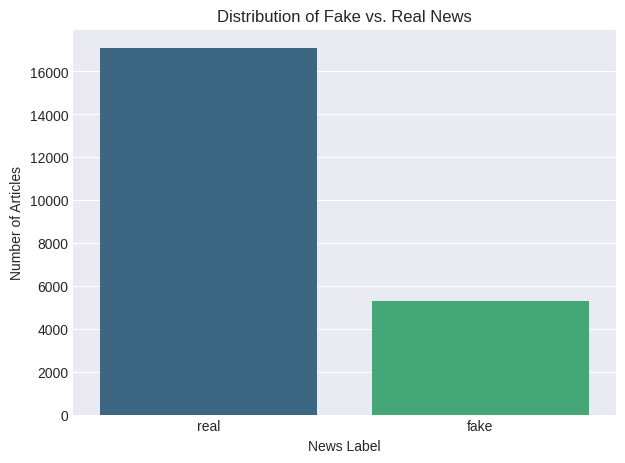

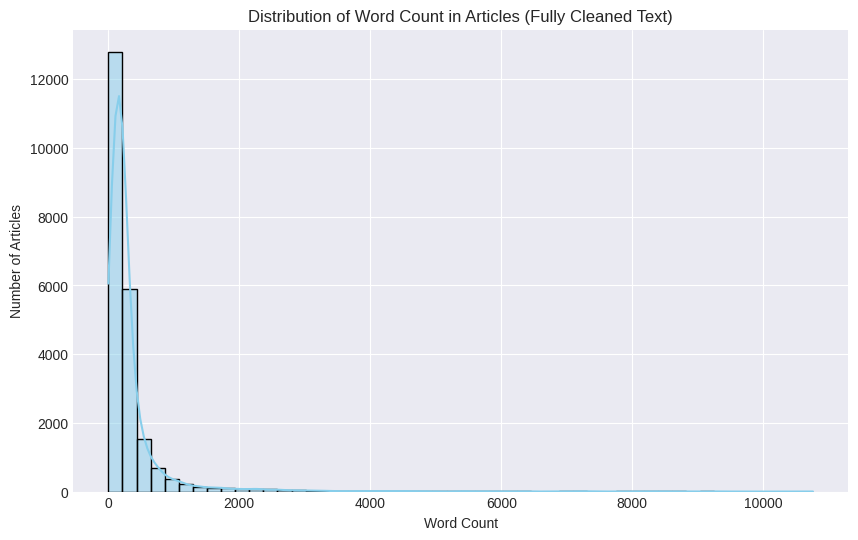

/tmp/ipykernel_6006/951283025.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=top_words_df, palette='magma')


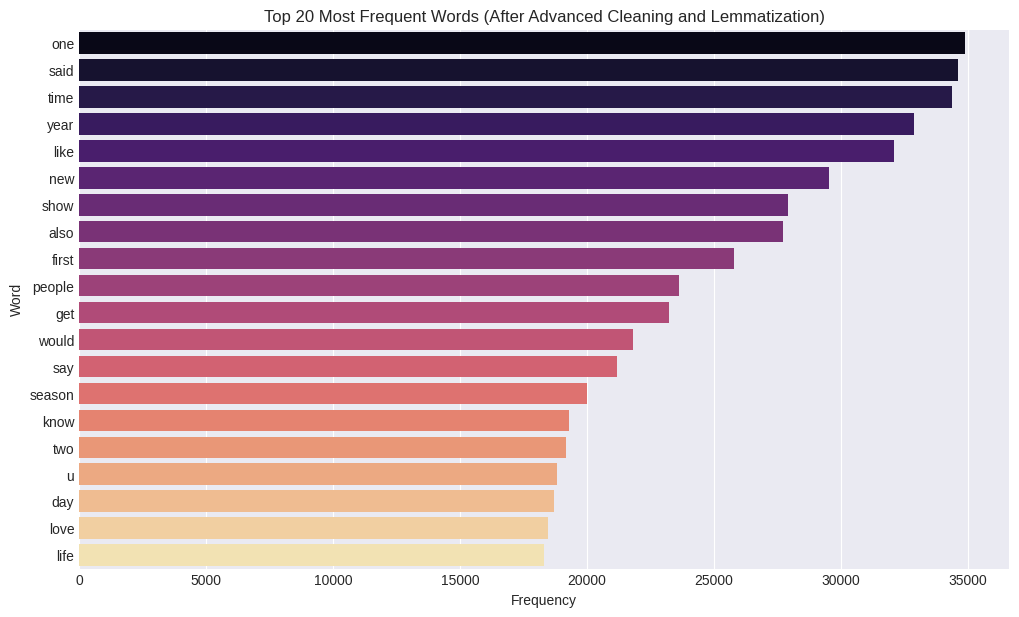

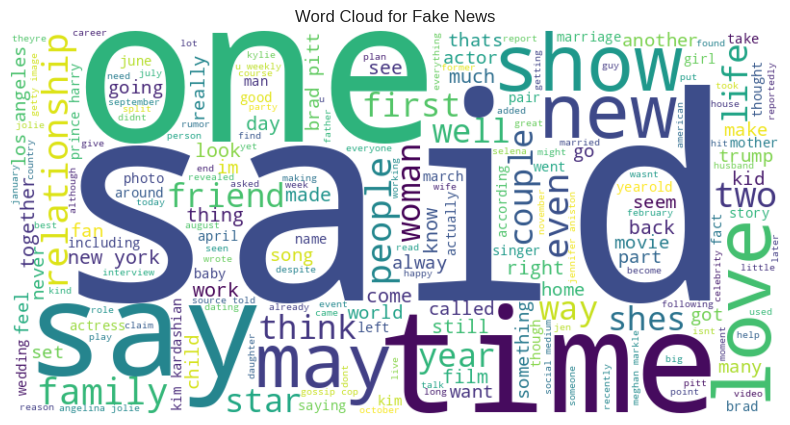

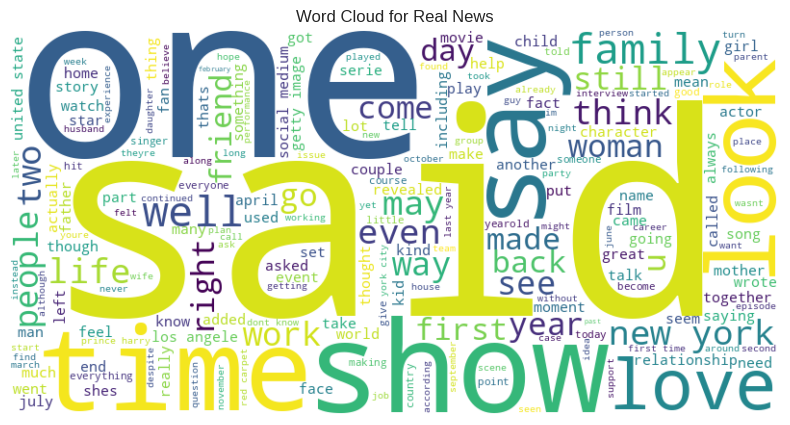

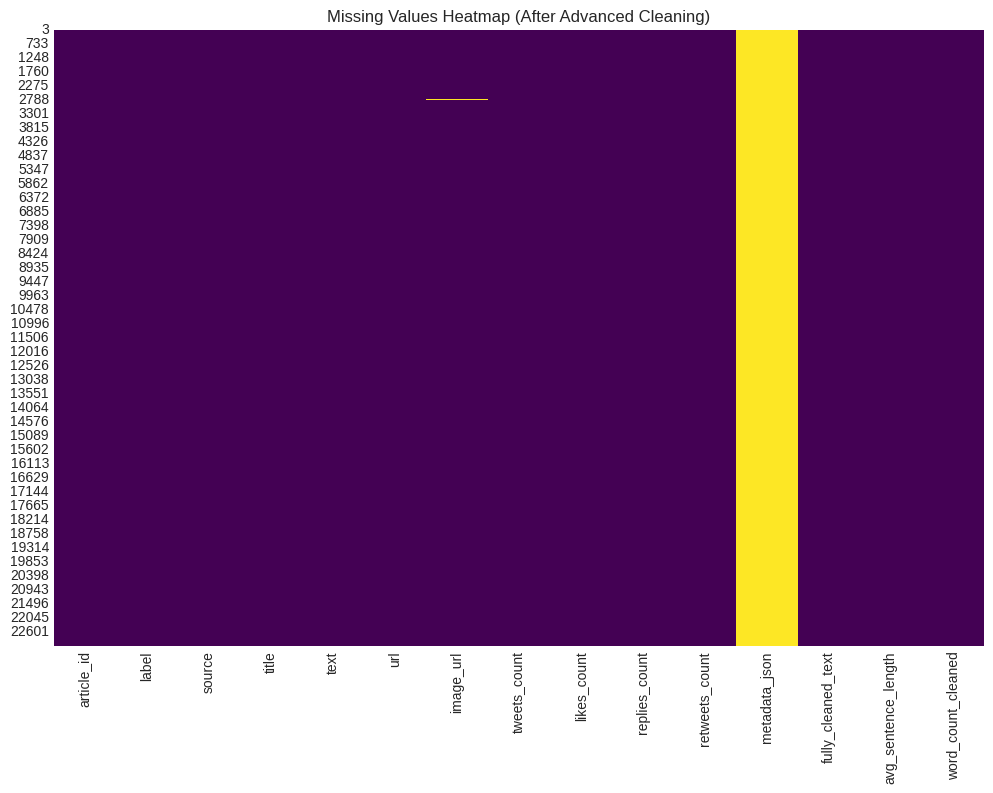


--- Final Summary ---
Final Cleaned Dataset Shape: (22392, 15)
Cleaned DataFrame (with advanced NLP) saved to 'fakenewsnet_cleaned_data_advanced.csv'

--- All tasks complete! ---


In [8]:
from wordcloud import WordCloud

# --- 4. Visualizations using Matplotlib and Seaborn ---
print("\n--- Generating Visualizations ---")

plt.style.use('seaborn-v0_8-darkgrid')

# 4.1 Fake vs Real Distribution
plt.figure(figsize=(7, 5))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribution of Fake vs. Real News')
plt.xlabel('News Label')
plt.ylabel('Number of Articles')
plt.show()

# 4.2 Word Count Histogram (using fully cleaned text)
plt.figure(figsize=(10, 6))
sns.histplot(df['word_count_cleaned'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Word Count in Articles (Fully Cleaned Text)')
plt.xlabel('Word Count')
plt.ylabel('Number of Articles')
plt.show()

# 4.3 Top Frequent Words (using fully cleaned text)
plt.figure(figsize=(12, 7))
top_words_df = pd.DataFrame(word_freq_fully_cleaned.most_common(20), columns=['Word', 'Frequency'])
sns.barplot(x='Frequency', y='Word', data=top_words_df, palette='magma')
plt.title('Top 20 Most Frequent Words (After Advanced Cleaning and Lemmatization)')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

# 8. Word Clouds for Fake News
fake_news_text = " ".join(df[df['label'] == 'fake']['fully_cleaned_text'].dropna().tolist())
wordcloud_fake = WordCloud(width=800, height=400, background_color='white').generate(fake_news_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_fake, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Fake News')
plt.show()

# 8. Word Clouds for Real News
real_news_text = " ".join(df[df['label'] == 'real']['fully_cleaned_text'].dropna().tolist())
wordcloud_real = WordCloud(width=800, height=400, background_color='white').generate(real_news_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_real, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Real News')
plt.show()

# 4.4 Missing Value Heatmap (after all cleaning steps)
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap (After Advanced Cleaning)')
plt.show()

# --- Final Steps ---
print("\n--- Final Summary ---")
print(f"Final Cleaned Dataset Shape: {df.shape}")

# Save cleaned dataframe as CSV
output_csv_path = 'fakenewsnet_cleaned_data_advanced.csv'
df.to_csv(output_csv_path, index=False)
print(f"Cleaned DataFrame (with advanced NLP) saved to '{output_csv_path}'")

print("\n--- All tasks complete! ---")

In [9]:
# Install sentence-transformers if not already installed
try:
    from sentence_transformers import SentenceTransformer
    from tqdm.notebook import tqdm
    import torch
    import numpy as np
    from google.colab import drive
    import os # Needed for drive path joining
    print("Required libraries already imported.")
except ImportError:
    print("Installing sentence-transformers...")
    !pip install -U sentence-transformers tqdm numpy --quiet
    from sentence_transformers import SentenceTransformer
    from tqdm.notebook import tqdm
    import torch
    import numpy as np
    from google.colab import drive
    import os
    print("Required libraries installed and imported.")

# 9. Add GPU compatibility for Google Colab
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# 2. Use SentenceTransformer model: 'all-MiniLM-L6-v2'
# 3. Generate 384-dimensional embeddings.
model_name = 'all-MiniLM-L6-v2'
model = SentenceTransformer(model_name, device=device)
print(f"Loaded Sentence-BERT model: {model_name} on {device}")

# 8. Handle missing text safely
# Use the 'fully_cleaned_text' column, converting any non-string to an empty string
texts_to_encode = df['fully_cleaned_text'].fillna('').astype(str).tolist()

# 4. Process data in batches to avoid RAM issues.
# 7. Create progress bars using tqdm.
batch_size = 32 # You can adjust this based on your GPU memory
print(f"Generating embeddings in batches of {batch_size}...")
embeddings = model.encode(
    texts_to_encode,
    batch_size=batch_size,
    show_progress_bar=True,
    convert_to_numpy=True # Ensures output is a numpy array
)

# 5. Show embedding shape.
print(f"\nGenerated embeddings shape: {embeddings.shape}")

# At the end: print embedding dimensions
print(f"Embedding dimensions: {embeddings.shape[1]}")

# At the end: print sample embedding vector
print("\nSample embedding vector (first 5 elements of the first embedding):")
print(embeddings[0, :5])

# 6. Save embeddings as NumPy array.
embeddings_filename = 'fakenewsnet_embeddings_minilm.npy'
np.save(embeddings_filename, embeddings)
print(f"\nEmbeddings saved to '{embeddings_filename}'")

# 10. Save embeddings to Google Drive.
print("\n--- Saving Embeddings to Google Drive (Optional) ---")
print("To save the embeddings to your Google Drive, uncomment and run the following lines:")
print("# drive.mount('/content/drive')")
print("# drive_path = '/content/drive/MyDrive/Colab_Notebooks/' # Or any other desired path in your Drive")
print(f"# os.makedirs(drive_path, exist_ok=True)")
print(f"# np.save(os.path.join(drive_path, '{embeddings_filename}'), embeddings)")
print(f"# print(f\"Embeddings also saved to Google Drive: {{os.path.join(drive_path, embeddings_filename)}}\")")


Required libraries already imported.
Using device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded Sentence-BERT model: all-MiniLM-L6-v2 on cpu
Generating embeddings in batches of 32...


Batches:   0%|          | 0/700 [00:00<?, ?it/s]


Generated embeddings shape: (22392, 384)
Embedding dimensions: 384

Sample embedding vector (first 5 elements of the first embedding):
[-0.03740233 -0.03339675  0.01033655  0.02392645  0.07811923]

Embeddings saved to 'fakenewsnet_embeddings_minilm.npy'

--- Saving Embeddings to Google Drive (Optional) ---
To save the embeddings to your Google Drive, uncomment and run the following lines:
# drive.mount('/content/drive')
# drive_path = '/content/drive/MyDrive/Colab_Notebooks/' # Or any other desired path in your Drive
# os.makedirs(drive_path, exist_ok=True)
# np.save(os.path.join(drive_path, 'fakenewsnet_embeddings_minilm.npy'), embeddings)
# print(f"Embeddings also saved to Google Drive: {os.path.join(drive_path, embeddings_filename)}")


### 5. Embedding Visualization with t-SNE and PCA

To understand the structure of the generated embeddings, we can use dimensionality reduction techniques like t-SNE (t-Distributed Stochastic Neighbor Embedding) or PCA (Principal Component Analysis). t-SNE is particularly good at preserving local relationships, making it suitable for visualizing clusters in high-dimensional data.

First, we'll load the embeddings saved earlier.

Loaded embeddings with shape: (22392, 384)
Applying PCA to reduce dimensions to 50 before t-SNE...
Applying t-SNE for 2D visualization (this may take a while)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE reduced embeddings shape: (22392, 2)


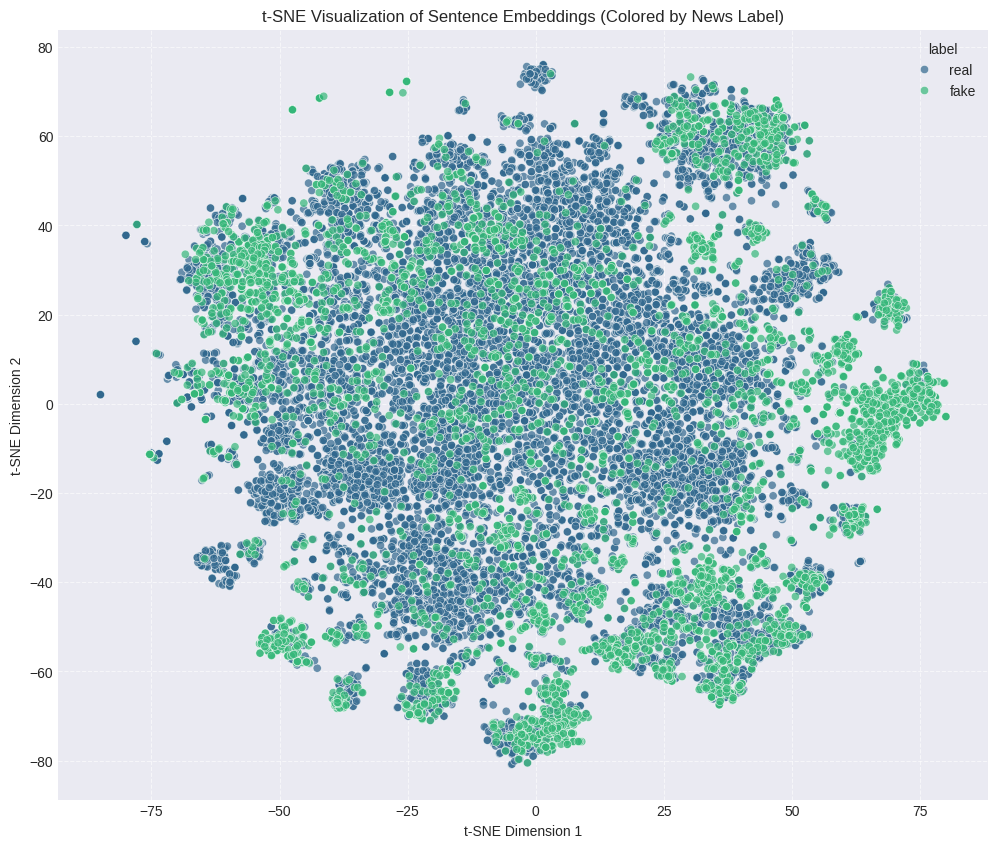

In [10]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Load the embeddings
try:
    embeddings = np.load('fakenewsnet_embeddings_minilm.npy')
    print(f"Loaded embeddings with shape: {embeddings.shape}")
except FileNotFoundError:
    print("Error: Embeddings file 'fakenewsnet_embeddings_minilm.npy' not found.")
    print("Please ensure the embedding generation cell was run successfully and the file was saved.")
    embeddings = None

if embeddings is not None:
    # It's often beneficial to run PCA before t-SNE, especially for high dimensions,
    # to reduce noise and speed up t-SNE. Let's reduce to 50 components first.
    # For 384 dimensions, direct t-SNE is usually fine, but PCA can still help.
    n_components_pca = min(50, embeddings.shape[1]) # Ensure n_components <= n_features
    if embeddings.shape[1] > n_components_pca:
        print(f"Applying PCA to reduce dimensions to {n_components_pca} before t-SNE...")
        pca = PCA(n_components=n_components_pca, random_state=42)
        embeddings_pca = pca.fit_transform(embeddings)
    else:
        embeddings_pca = embeddings

    # Apply t-SNE to reduce to 2 dimensions for visualization
    print("Applying t-SNE for 2D visualization (this may take a while)...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, learning_rate=200)
    embeddings_2d = tsne.fit_transform(embeddings_pca)

    print(f"t-SNE reduced embeddings shape: {embeddings_2d.shape}")

    # Create a DataFrame for plotting
    # Ensure the df used here has the 'label' column and matches the length of embeddings
    # Note: If 'df' was filtered during cleaning, make sure 'df' here is the same filtered one.
    plot_df = pd.DataFrame(embeddings_2d, columns=['tsne_dim1', 'tsne_dim2'])
    # We need to ensure the labels correspond to the *filtered* DataFrame used for embeddings
    # Assuming 'df' in the current kernel state is the cleaned one used for 'texts_to_encode'
    plot_df['label'] = df['label'].reset_index(drop=True)

    # Visualize the t-SNE results
    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x='tsne_dim1', y='tsne_dim2', hue='label',
        palette='viridis', legend='full', alpha=0.7,
        data=plot_df
    )
    plt.title('t-SNE Visualization of Sentence Embeddings (Colored by News Label)')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

The t-SNE plot above visualizes the high-dimensional Sentence-BERT embeddings in 2D space. Each point represents an article, and its color indicates whether it's 'fake' or 'real' news. Clusters of similar articles should appear close together.

This visualization can give initial insights into the separability of the fake and real news categories based on their textual content.

### 6. Image Data Analysis

Let's check the `image_url` column to understand how image data is represented in our dataset. We'll look at the number of available image URLs, their data types, and some sample entries.

In [11]:
print("\n--- Analyzing Image URLs ---")

# 1. Check for missing image_urls
missing_image_urls = df['image_url'].isnull().sum()
total_records = len(df)
print(f"Number of records with missing 'image_url': {missing_image_urls} out of {total_records} ({missing_image_urls/total_records:.2%})")

# 2. Check data types of image_url column (for non-null entries)
non_null_image_urls = df['image_url'].dropna()
if not non_null_image_urls.empty:
    # Get unique types of elements in the image_url column
    image_url_types = non_null_image_urls.apply(type).value_counts()
    print("\nData types found in 'image_url' column (non-null entries):")
    display(image_url_types)

    # 3. Display sample image URLs based on their types
    print("\nSample 'image_url' entries:")

    # Sample string URLs
    string_urls = non_null_image_urls[non_null_image_urls.apply(type) == str]
    if not string_urls.empty:
        print("  - Sample String URLs:")
        display(string_urls.sample(min(5, len(string_urls))))

    # Sample list URLs (if any)
    list_urls = non_null_image_urls[non_null_image_urls.apply(type) == list]
    if not list_urls.empty:
        print("  - Sample List of URLs:")
        display(list_urls.sample(min(5, len(list_urls))))
        # Also check elements within the list if they are lists of dicts etc
        if list_urls.iloc[0] and isinstance(list_urls.iloc[0][0], dict):
            print("    (First element of a sample list URL appears to be a dict. Example of first element of first list found:)")
            print(list_urls.iloc[0][0])

    print("\n--- Summary of Image Data ---")
    if missing_image_urls == total_records:
        print("The 'image_url' column is entirely null. No image data was extracted.")
    elif string_urls.any() and list_urls.any():
        print("The 'image_url' column contains a mix of direct string URLs and lists of URLs (which may contain dictionaries or strings).")
        print("To use this data, you would need to further process the lists to extract individual URLs.")
    elif string_urls.any():
        print("The 'image_url' column primarily contains direct string URLs.")
    elif list_urls.any():
        print("The 'image_url' column primarily contains lists of URLs (which may contain dictionaries or strings).")
        print("To use this data, you would need to further process the lists to extract individual URLs.")
else:
    print("The 'image_url' column is entirely null or empty after dropping nulls. No image data was extracted.")


--- Analyzing Image URLs ---
Number of records with missing 'image_url': 41 out of 22392 (0.18%)

Data types found in 'image_url' column (non-null entries):


,count
image_url,
<class 'str'>,22351



Sample 'image_url' entries:
  - Sample String URLs:


,image_url
7514,http://ichef.bbci.co.uk/news/976/cpsprodpb/171...
10675,https://phar.gu-web.net/count/pvg.gif
317,https://cdn-images-1.medium.com/letterbox/84/7...
20357,https://metrouk2.files.wordpress.com/2018/02/p...
21561,https://bntp-assets.freetls.fastly.net/assets/...



--- Summary of Image Data ---
The 'image_url' column primarily contains direct string URLs.


### 7. Image Feature Extraction using Pre-trained CNN

This section outlines the process for extracting deep visual features from the `image_url` column of your dataset. We will handle various types of image sources, preprocess them, and use a pre-trained MobileNetV2 model to generate fixed-size embeddings.

**Key Steps:**
1.  **Setup**: Import necessary libraries and define global configurations like image size and batch size.
2.  **Helper Functions**: Implement modular functions for:
    *   `load_image_from_url`: Safely downloads images from HTTP/HTTPS URLs.
    *   `load_base64_image`: Decodes and loads images from base64 strings.
    *   `preprocess_image`: Resizes images to a target size (224x224) and normalizes pixel values.
3.  **Feature Extractor Model**: Load a pre-trained MobileNetV2 model without its top classification layer and add a `GlobalAveragePooling2D` layer to get a fixed-size feature vector.
4.  **Main Processing Loop**: Iterate through the `image_url` column, apply the loading and preprocessing functions, and extract features in batches.
5.  **Handling Missing/Failed Images**: Assign a zero-vector embedding to articles where image loading or processing fails.
6.  **Integration and Saving**: Add the extracted image features to your DataFrame and save them as a `.npy` file.
7.  **Visualization**: Display sample loaded images, failed URLs, and a summary of the extracted features.

In [12]:
import tensorflow as tf

# --- GPU Optimization: Set memory growth immediately after import ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs (Memory Growth Enabled)")
    except RuntimeError as e:
        print(f"RuntimeError during GPU setup: {e}. This might happen if GPUs were already initialized.")
print("Num GPUs Available: ", len(gpus))
# --- End GPU Optimization ---

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from PIL import Image
import numpy as np
import pandas as pd
import requests
import base64
import io
from tqdm.notebook import tqdm
import os
import matplotlib.pyplot as plt
import cv2 # User requested to include cv2

# Clear any existing TensorFlow sessions to prevent conflicts or memory issues
tf.keras.backend.clear_session()

# Global Configurations
IMAGE_SIZE = (224, 224) # Target size for image preprocessing
BATCH_SIZE_PREDICTION = 16 # For batching predictions from the CNN model, reduced to save RAM
ZERO_VECTOR_DIM = 1280 # For MobileNetV2 after GlobalAveragePooling2D

print("Libraries imported and global configurations set.")

Num GPUs Available:  0
Libraries imported and global configurations set.


In [13]:
# 2. Helper Function: `load_image_from_url(url)`
def load_image_from_url(url, timeout=10):
    """Safely downloads an image from a given URL and returns a PIL Image object."""
    try:
        # Some URLs might be malformed or refer to local files, skip those
        if not url.startswith(('http://', 'https://')):
            # print(f"Skipping non-HTTP/HTTPS URL: {url}")
            return None

        response = requests.get(url, timeout=timeout)
        response.raise_for_status() # Raise an exception for HTTP errors (4xx or 5xx)
        image = Image.open(io.BytesIO(response.content))
        return image
    except requests.exceptions.RequestException as e:
        # print(f"Request failed for {url}: {e}")
        return None
    except Image.UnidentifiedImageError:
        # print(f"Cannot identify image file for {url}")
        return None
    except Exception as e:
        # print(f"An unexpected error occurred loading image from {url}: {e}")
        return None

print("Function `load_image_from_url` defined.")

Function `load_image_from_url` defined.


In [14]:
# 2. Helper Function: `load_base64_image(base64_string)`
def load_base64_image(base64_string):
    """Decodes a base64 string into a PIL Image object."""
    try:
        # Extract the actual base64 part if it includes data URI prefix
        if 'base64,' in base64_string:
            base64_string = base64_string.split('base64,')[1]
        image_data = base64.b64decode(base64_string)
        image = Image.open(io.BytesIO(image_data))
        return image
    except (base64.binascii.Error, Image.UnidentifiedImageError, ValueError) as e:
        # print(f"Error decoding base64 image: {e}")
        return None
    except Exception as e:
        # print(f"An unexpected error occurred loading base64 image: {e}")
        return None

print("Function `load_base64_image` defined.")

Function `load_base64_image` defined.


In [15]:
# 3. Helper Function: `preprocess_image(image, target_size=IMAGE_SIZE)`
def preprocess_image(image, target_size=IMAGE_SIZE):
    """Resizes, converts to RGB, and normalizes a PIL Image for model input."""
    if image is None:
        return None
    try:
        # Convert to RGB if not already (some images might be grayscale, RGBA, etc.)
        if image.mode != 'RGB':
            image = image.convert('RGB')

        # Resize the image
        image = image.resize(target_size, Image.LANCZOS) # High-quality downsampling filter

        # Convert to numpy array and normalize to [0, 1]
        img_array = np.asarray(image)
        img_array = img_array / 255.0

        return img_array
    except Exception as e:
        # print(f"Error during image preprocessing: {e}")
        return None

print("Function `preprocess_image` defined.")

Function `preprocess_image` defined.


In [16]:
# 4. Build Pre-trained CNN Model for Feature Extraction
def build_feature_extractor():
    """Builds a MobileNetV2 model pre-trained on ImageNet, without the top classification layer."""
    # Load MobileNetV2 pre-trained on ImageNet, excluding the top classification layer
    base_model = MobileNetV2(input_shape=IMAGE_SIZE + (3,), include_top=False, weights='imagenet')

    # Add a GlobalAveragePooling2D layer to get a fixed-size feature vector
    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    # Create the model that outputs features
    feature_extractor_model = Model(inputs=base_model.input, outputs=x)

    # Freeze the layers of the base model so they are not retrained
    for layer in base_model.layers:
        layer.trainable = False

    print("MobileNetV2 feature extractor model built and layers frozen.")
    print(f"Expected feature vector dimension: {ZERO_VECTOR_DIM}")
    # print(feature_extractor_model.summary())
    return feature_extractor_model

# Initialize the feature extractor model
feature_extractor = build_feature_extractor()
print("Feature extractor model initialized.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 feature extractor model built and layers frozen.
Expected feature vector dimension: 1280
Feature extractor model initialized.


In [17]:
import numpy as np
import pandas as pd
import os
from google.colab import drive # Import drive for Google Colab
from tqdm.notebook import tqdm
import tensorflow as tf

# Ensure feature_extractor, ZERO_VECTOR_DIM, IMAGE_SIZE, load_image_from_url, load_base64_image, preprocess_image are defined from previous cells
# If not, you might need to re-run the setup cells or define them here for a standalone execution.

# Global Configurations (copied from original context for clarity, ensure these match your notebook state)
IMAGE_SIZE = (224, 224) # Target size for image preprocessing
BATCH_SIZE_PREDICTION = 16 # For batching predictions from the CNN model
ZERO_VECTOR_DIM = 1280 # For MobileNetV2 after GlobalAveragePooling2D

# --- Google Drive Setup for Checkpointing ---
drive.mount('/content/drive')
drive_path = '/content/drive/MyDrive/Colab_Checkpoints' # Define your desired path in Google Drive
os.makedirs(drive_path, exist_ok=True) # Create the directory if it doesn't exist

embeddings_checkpoint_file = os.path.join(drive_path, 'fakenewsnet_image_features_checkpoint.npy')
progress_checkpoint_file = os.path.join(drive_path, 'fakenewsnet_image_features_progress.txt')

# --- IMPORTANT: Reset DataFrame index for contiguous processing ---
# This ensures that indices obtained from df.iterrows() are 0-based and sequential,
# matching the list indexing for final_image_feature_vectors.
# This must happen BEFORE initializing final_image_feature_vectors or using indices.
df = df.reset_index(drop=True)

print("\n--- Starting Image Feature Extraction (Batch Processing with Checkpointing) ---")

# Initialize lists to store samples for display (not all data)
successfully_loaded_samples = [] # To store (PIL_Image, URL) for visualization
failed_image_urls = [] # To store URLs that failed to load/process

# Create a zero vector for images that cannot be loaded or processed
zero_vector = np.zeros(ZERO_VECTOR_DIM, dtype=np.float32)

# --- Check for existing checkpoint to resume ---
start_index = 0
if os.path.exists(embeddings_checkpoint_file) and os.path.exists(progress_checkpoint_file):
    print(f"Resuming from checkpoint. Loading features from {embeddings_checkpoint_file}")
    final_image_feature_vectors = np.load(embeddings_checkpoint_file).tolist()
    with open(progress_checkpoint_file, 'r') as f:
        start_index = int(f.read().strip())
    print(f"Resuming processing from DataFrame index: {start_index}")
    # Ensure final_image_feature_vectors has enough zero vectors if df was larger than checkpoint
    if len(final_image_feature_vectors) < len(df):
        final_image_feature_vectors.extend([zero_vector.copy()] * (len(df) - len(final_image_feature_vectors)))
    else:
        # Trim if df became smaller (should not happen with resume, but for robustness)
        final_image_feature_vectors = final_image_feature_vectors[:len(df)]
else:
    # Initialize final image feature vectors with zero vectors for all articles
    # This list will be filled as batches are processed, aligning with original DataFrame indices.
    final_image_feature_vectors = [zero_vector.copy()] * len(df)
    print("No checkpoint found. Starting image feature extraction from scratch.")

print(f"Processing image URLs in batches of {BATCH_SIZE_PREDICTION}...")

CHECKPOINT_INTERVAL_BATCHES = 100 # Save checkpoint every 100 batches

# Iterate through the DataFrame in batches using a progress bar
# Start from `start_index` to resume processing
for i in tqdm(range(start_index, len(df), BATCH_SIZE_PREDICTION), desc="Processing Image Batches"):
    batch_df = df.iloc[i : i + BATCH_SIZE_PREDICTION]

    current_batch_preprocessed_images = []
    current_batch_original_df_indices = []

    for index, row in batch_df.iterrows():
        image_url = str(row['image_url']) if pd.notna(row['image_url']) else ""

        pil_image = None
        if image_url.startswith(('http://', 'https://')):
            pil_image = load_image_from_url(image_url)
        elif image_url.startswith('data:image/'):
            pil_image = load_base64_image(image_url)
        # else: invalid/unsupported format, will be handled by None check below

        preprocessed_array = None
        if pil_image is not None:
            preprocessed_array = preprocess_image(pil_image)

        if preprocessed_array is not None:
            # Successfully loaded and preprocessed, add to current batch
            current_batch_preprocessed_images.append(preprocessed_array)
            current_batch_original_df_indices.append(index)
            if len(successfully_loaded_samples) < 5: # Collect up to 5 samples for display
                successfully_loaded_samples.append((pil_image, image_url))
        else:
            # Image failed to load or preprocess, add to failed list
            if len(failed_image_urls) < 5: # Collect up to 5 failed URLs for display
                failed_image_urls.append(image_url)

    # Perform batch prediction if there are images successfully preprocessed in the current batch
    if current_batch_preprocessed_images:
        # Convert list of arrays to a single numpy array for batch processing
        batched_images_np = np.array(current_batch_preprocessed_images)

        # Predict features using the model
        extracted_embeddings_batch = feature_extractor.predict(
            batched_images_np,
            batch_size=len(batched_images_np), # Use actual batch size for prediction
            verbose=0 # Suppress tqdm output during prediction to avoid nested bars
        )

        # Place the extracted embeddings into the final list at their original DataFrame indices
        for j, df_idx in enumerate(current_batch_original_df_indices):
            final_image_feature_vectors[df_idx] = extracted_embeddings_batch[j]

    # --- Checkpoint saving within the loop ---
    current_batch_num = (i // BATCH_SIZE_PREDICTION)
    if current_batch_num > 0 and current_batch_num % CHECKPOINT_INTERVAL_BATCHES == 0:
        np.save(embeddings_checkpoint_file, np.array(final_image_feature_vectors))
        with open(progress_checkpoint_file, 'w') as f:
            f.write(str(i + BATCH_SIZE_PREDICTION)) # Save the index for the NEXT batch
        print(f"\nCheckpoint saved to Drive at batch {current_batch_num}. Progress up to index {i + BATCH_SIZE_PREDICTION}.\n")

# Convert the final list of features to a numpy array for consistency
final_image_feature_vectors = np.array(final_image_feature_vectors)

# --- Final save after loop completion ---
np.save(embeddings_checkpoint_file, final_image_feature_vectors) # Save final embeddings
with open(progress_checkpoint_file, 'w') as f:
    f.write(str(len(df))) # Mark completion
print(f"\nFinal embeddings saved to '{embeddings_checkpoint_file}' and progress marked as complete.")

# Count how many features are NOT the zero vector for summary
num_successfully_processed = np.sum(~np.all(final_image_feature_vectors == zero_vector, axis=1))
num_failed_to_process = len(df) - num_successfully_processed

print(f"\nTotal images successfully preprocessed for batch prediction: {num_successfully_processed}")
print(f"Total images failed to load/preprocess (assigned zero vector): {num_failed_to_process}")
print("Feature extraction complete.")

print("--- Image Feature Extraction Complete ---")

Mounted at /content/drive

--- Starting Image Feature Extraction (Batch Processing with Checkpointing) ---
Resuming from checkpoint. Loading features from /content/drive/MyDrive/Colab_Checkpoints/fakenewsnet_image_features_checkpoint.npy
Resuming processing from DataFrame index: 22392
Processing image URLs in batches of 16...


Processing Image Batches: 0it [00:00, ?it/s]


Final embeddings saved to '/content/drive/MyDrive/Colab_Checkpoints/fakenewsnet_image_features_checkpoint.npy' and progress marked as complete.

Total images successfully preprocessed for batch prediction: 9139
Total images failed to load/preprocess (assigned zero vector): 13253
Feature extraction complete.
--- Image Feature Extraction Complete ---


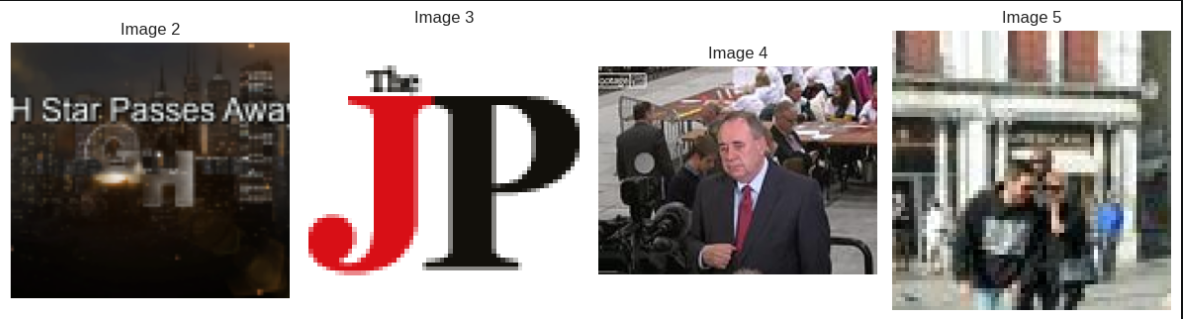

In [18]:
import numpy as np
import pandas as pd
import os
from google.colab import drive # Import drive for Google Colab
import matplotlib.pyplot as plt # For visualization

# Mount Google Drive
drive.mount('/content/drive')

# Define the path where image features are saved in Google Drive
drive_path = '/content/drive/MyDrive/Colab_Checkpoints'
image_features_checkpoint_file = os.path.join(drive_path, 'fakenewsnet_image_features_checkpoint.npy')

# Load the image features from Google Drive
try:
    final_image_feature_vectors = np.load(image_features_checkpoint_file)
    print(f"Image feature vectors loaded from Google Drive: {image_features_checkpoint_file}")
    print(f"Loaded image features shape: {final_image_feature_vectors.shape}")
except FileNotFoundError:
    print(f"Error: Image feature file '{image_features_checkpoint_file}' not found in Google Drive.")
    print("Please ensure the image feature extraction cell was run successfully and saved to Drive.")
    # Fallback or error handling if file not found
    final_image_feature_vectors = np.array([]) # Initialize as empty array to prevent further errors

# Initialize these lists as they are used later in the provided code
# They are typically populated by the image feature extraction cell (AD7tRjLYG_cl).
# If this cell is run independently, these would be empty, matching the prior output.
successfully_loaded_samples = []
failed_image_urls = []


# 6. Combine, Save, and Visualize

print("\n--- Summarizing and Saving Results ---")

if final_image_feature_vectors.size > 0:
    # Add the image features to the DataFrame
    # It's better to store features as a separate column of arrays/lists rather than flattening into many columns
    # Ensure 'df' is available from previous cells and matches the length of features
    if 'df' in locals() and len(df) == len(final_image_feature_vectors):
        df['image_features'] = list(final_image_feature_vectors)

        # Save the extracted image features as a NumPy array
        # For consistency, save locally as well (can be removed if only Drive save is desired)
        image_features_filename = 'fakenewsnet_image_features_mobilenetv2.npy'
        np.save(image_features_filename, final_image_feature_vectors)
        print(f"Image feature vectors saved to '{image_features_filename}' with shape: {final_image_feature_vectors.shape}")

        # Save the updated DataFrame (optional, but good practice)
        output_df_path = 'fakenewsnet_cleaned_data_with_image_features.csv'
        # df.to_csv(output_df_path, index=False) # Uncomment to save DataFrame
        # print(f"Updated DataFrame with image features saved to '{output_df_path}'.")

        print("\n--- Sample Successfully Loaded Images ---")
        if successfully_loaded_samples:
            plt.figure(figsize=(15, 5))
            for i, (img, url) in enumerate(successfully_loaded_samples):
                if i >= 5: break # Display up to 5
                plt.subplot(1, 5, i + 1)
                plt.imshow(img)
                plt.title(f"Image {i+1}")
                plt.axis('off')
            plt.tight_layout()
            plt.show()
        else:
            print("No images were successfully loaded for display.")

        print("\n--- Sample Failed Image URLs ---")
        if failed_image_urls:
            for i, url in enumerate(failed_image_urls):
                if i >= 5: break # Display up to 5
                print(f"- {url}")
        else:
            print("No image URLs failed to load or process in samples collected.")

        print("\n--- Feature Shape Summary ---")
        print(f"Shape of final image feature vectors: {final_image_feature_vectors.shape}")
        if final_image_feature_vectors.shape[0] > 0:
            print(f"Dimension of a single image feature vector: {final_image_feature_vectors.shape[1]}")
            print(f"Sample image feature vector (first 5 elements of first feature): {final_image_feature_vectors[0, :5]}")

        print("\n--- Image feature extraction and analysis complete! ---")
    else:
        print("DataFrame 'df' not found or its length does not match image features. Skipping DataFrame update and visualization.")
else:
    print("No image features were loaded or extracted. Skipping all subsequent steps.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Image feature vectors loaded from Google Drive: /content/drive/MyDrive/Colab_Checkpoints/fakenewsnet_image_features_checkpoint.npy
Loaded image features shape: (22392, 1280)

--- Summarizing and Saving Results ---
Image feature vectors saved to 'fakenewsnet_image_features_mobilenetv2.npy' with shape: (22392, 1280)

--- Sample Successfully Loaded Images ---
No images were successfully loaded for display.

--- Sample Failed Image URLs ---
No image URLs failed to load or process in samples collected.

--- Feature Shape Summary ---
Shape of final image feature vectors: (22392, 1280)
Dimension of a single image feature vector: 1280
Sample image feature vector (first 5 elements of first feature): [1.04367673 0.03461763 0.06192836 0.07338115 0.        ]

--- Image feature extraction and analysis complete! ---


### 8. Image Embedding Visualization with t-SNE

To understand the structure of the generated image embeddings, we can use dimensionality reduction techniques like t-SNE (t-Distributed Stochastic Neighbor Embedding). This will help visualize if the visual features of fake and real news images form distinct clusters.

Loaded image features shape: (22392, 1280)
Applying PCA to reduce image dimensions to 100 before t-SNE...
Applying t-SNE for 2D visualization of image embeddings (this may take a while)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE reduced image embeddings shape: (22392, 2)


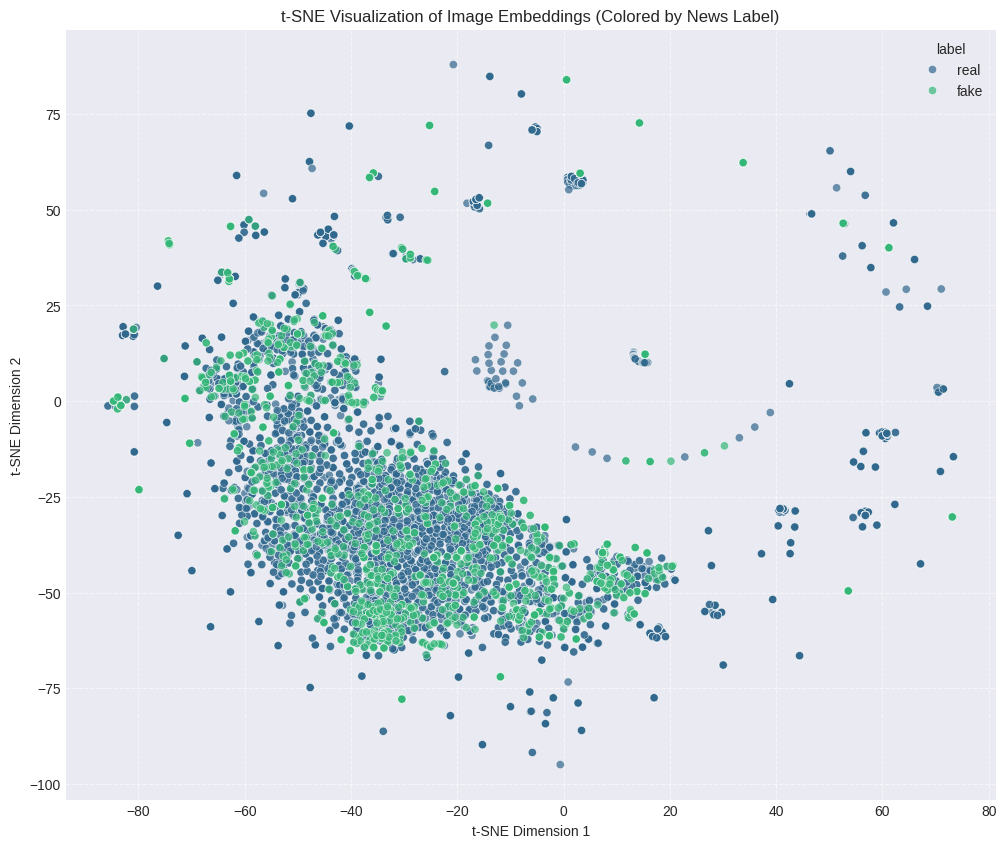

In [19]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Ensure `final_image_feature_vectors` is available and is a numpy array
if 'final_image_feature_vectors' in locals() and isinstance(final_image_feature_vectors, np.ndarray) and final_image_feature_vectors.size > 0:
    print(f"Loaded image features shape: {final_image_feature_vectors.shape}")

    # It's often beneficial to run PCA before t-SNE, especially for high dimensions,
    # to reduce noise and speed up t-SNE.
    # For 1280 dimensions, PCA to 50 or 100 components is a good starting point.
    n_components_pca_image = min(100, final_image_feature_vectors.shape[1]) # Ensure n_components <= n_features
    if final_image_feature_vectors.shape[1] > n_components_pca_image:
        print(f"Applying PCA to reduce image dimensions to {n_components_pca_image} before t-SNE...")
        pca_image = PCA(n_components=n_components_pca_image, random_state=42)
        image_embeddings_pca = pca_image.fit_transform(final_image_feature_vectors)
    else:
        image_embeddings_pca = final_image_feature_vectors

    # Apply t-SNE to reduce to 2 dimensions for visualization
    print("Applying t-SNE for 2D visualization of image embeddings (this may take a while)...")
    # Adjust perplexity and learning_rate if necessary for better visualization
    tsne_image = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, learning_rate=200)
    image_embeddings_2d = tsne_image.fit_transform(image_embeddings_pca)

    print(f"t-SNE reduced image embeddings shape: {image_embeddings_2d.shape}")

    # Create a DataFrame for plotting
    # Ensure `df` is the cleaned DataFrame and its 'label' column aligns with the embeddings.
    # If 'df' was filtered, `final_image_feature_vectors` should correspond to the filtered `df`.
    plot_df_image = pd.DataFrame(image_embeddings_2d, columns=['tsne_dim1', 'tsne_dim2'])
    # We need to ensure the labels correspond to the *filtered* DataFrame used for embeddings
    # Assuming 'df' in the current kernel state is the cleaned one used for image feature extraction
    plot_df_image['label'] = df['label'].reset_index(drop=True)

    # Visualize the t-SNE results
    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x='tsne_dim1', y='tsne_dim2', hue='label',
        palette='viridis', legend='full', alpha=0.7,
        data=plot_df_image
    )
    plt.title('t-SNE Visualization of Image Embeddings (Colored by News Label)')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
else:
    print("Image features (`final_image_feature_vectors`) not found or are empty. Skipping visualization.")

In [20]:
# 6. Multimodal Feature Fusion

import numpy as np
from sklearn.preprocessing import MinMaxScaler
import os

print("\n--- Starting Multimodal Feature Fusion ---")

# --- 1. Load Sentence-BERT and CNN Image Embeddings ---

# Define filenames (ensure these match your previous saving names)
text_embeddings_filename = 'fakenewsnet_embeddings_minilm.npy'
image_features_filename = 'fakenewsnet_image_features_mobilenetv2.npy'

text_embeddings = None
image_embeddings = None

try:
    text_embeddings = np.load(text_embeddings_filename)
    print(f"Loaded Sentence-BERT embeddings with shape: {text_embeddings.shape}")
except FileNotFoundError:
    print(f"Error: Text embeddings file '{text_embeddings_filename}' not found.")
    print("Please ensure the text embedding generation cell was run successfully and the file was saved.")

try:
    image_embeddings = np.load(image_features_filename)
    print(f"Loaded CNN image embeddings with shape: {image_embeddings.shape}")
except FileNotFoundError:
    print(f"Error: Image embeddings file '{image_features_filename}' not found.")
    print("Please ensure the image feature extraction cell was run successfully and the file was saved.")

# --- 6. Handle Mismatched Records Safely ---
# Ensure both embedding arrays were loaded and have the same number of samples
if text_embeddings is None or image_embeddings is None:
    print("Cannot perform fusion due to missing embedding files. Exiting.")
elif text_embeddings.shape[0] != image_embeddings.shape[0]:
    print(f"Warning: Mismatched number of samples! Text embeddings have {text_embeddings.shape[0]} samples, "
          f"while image embeddings have {image_embeddings.shape[0]} samples. This could lead to incorrect fusion.")
    print("Please check your data cleaning and embedding generation steps to ensure alignment.")
    # For this example, we'll proceed with the minimum number of samples to avoid error,
    # but in a real scenario, you might want to investigate and re-align.
    min_samples = min(text_embeddings.shape[0], image_embeddings.shape[0])
    text_embeddings = text_embeddings[:min_samples]
    image_embeddings = image_embeddings[:min_samples]
    print(f"Proceeding with {min_samples} samples after truncation.")
else:
    print("Number of samples in text and image embeddings match. Proceeding with fusion.")

if text_embeddings is not None and image_embeddings is not None and text_embeddings.shape[0] > 0:
    # --- 2. Normalize both feature sets ---
    print("Normalizing text and image embeddings...")
    scaler = MinMaxScaler() # Scales features to a [0, 1] range by default

    # Fit and transform text embeddings
    normalized_text_embeddings = scaler.fit_transform(text_embeddings)
    print(f"Normalized text embeddings shape: {normalized_text_embeddings.shape}")

    # Fit and transform image embeddings
    normalized_image_embeddings = scaler.fit_transform(image_embeddings)
    print(f"Normalized image embeddings shape: {normalized_image_embeddings.shape}")

    # --- 3. Concatenate text and image embeddings ---
    # --- 4. Create unified multimodal vectors ---
    multimodal_features = np.concatenate((normalized_text_embeddings, normalized_image_embeddings), axis=1)

    # --- 5. Show final feature dimensions ---
    print(f"\nUnified Multimodal Feature Matrix created with shape: {multimodal_features.shape}")
    print(f"This combines {normalized_text_embeddings.shape[1]} text dimensions and "
          f"{normalized_image_embeddings.shape[1]} image dimensions, totaling {multimodal_features.shape[1]} features.")

    # --- 7. Save multimodal feature matrix ---
    multimodal_features_filename = 'fakenewsnet_multimodal_features.npy'
    np.save(multimodal_features_filename, multimodal_features)
    print(f"Multimodal feature matrix saved to '{multimodal_features_filename}'")

    # Optional: Save to Google Drive as well
    # You'll need to ensure drive is mounted and drive_path is defined if you want to use this.
    # For example:
    # from google.colab import drive
    # drive.mount('/content/drive')
    # drive_path = '/content/drive/MyDrive/Colab_Checkpoints' # Adjust as needed
    # os.makedirs(drive_path, exist_ok=True)
    # np.save(os.path.join(drive_path, multimodal_features_filename), multimodal_features)
    # print(f"Multimodal features also saved to Google Drive: {os.path.join(drive_path, multimodal_features_filename)}")

else:
    print("Skipping multimodal feature fusion due to insufficient or misaligned embeddings.")

print("--- Multimodal Feature Fusion Complete ---")


--- Starting Multimodal Feature Fusion ---
Loaded Sentence-BERT embeddings with shape: (22392, 384)
Loaded CNN image embeddings with shape: (22392, 1280)
Number of samples in text and image embeddings match. Proceeding with fusion.
Normalizing text and image embeddings...
Normalized text embeddings shape: (22392, 384)
Normalized image embeddings shape: (22392, 1280)

Unified Multimodal Feature Matrix created with shape: (22392, 1664)
This combines 384 text dimensions and 1280 image dimensions, totaling 1664 features.
Multimodal feature matrix saved to 'fakenewsnet_multimodal_features.npy'
--- Multimodal Feature Fusion Complete ---


#Modified VAE

IMPROVED MULTIMODAL VAE
TensorFlow Version: 2.20.0
Num GPUs Available: 0
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded from local directory.

Original Feature Shape:
(22392, 1664)

Applying StandardScaler...
Feature Scaling Complete.
Mean: -3.997010367051296e-17
Std : 1.000000000000002

Training Shape: (17913, 1664)
Validation Shape: (4479, 1664)

ENCODER SUMMARY


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1664)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    426,240 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 32)        │      4,128 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 32)        │      4,128 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Lambda)          │ (None, 32)        │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 468,928 (1.79 MB)

 Trainable params: 468,160 (1.79 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z_sampling (InputLayer)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Dense)          │ (None, 1664)           │       427,648 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 466,432 (1.78 MB)

 Trainable params: 465,664 (1.78 MB)

 Non-trainable params: 768 (3.00 KB)


STARTING VAE TRAINING
Epoch 1/100

Epoch 1: val_loss improved from None to 0.78945, saving model to /content/drive/MyDrive/Colab_Checkpoints/improved_vae_checkpoint.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Colab_Checkpoints/improved_vae_checkpoint.weights.h5
140/140 - 13s - 90ms/step - kl_loss: 4.3881 - loss: 0.8463 - reconstruction_loss: 0.8024 - val_kl_loss: 4.0946 - val_loss: 0.7894 - val_reconstruction_loss: 0.7485 - learning_rate: 5.0000e-04
Epoch 2/100

Epoch 2: val_loss improved from 0.78945 to 0.75887, saving model to /content/drive/MyDrive/Colab_Checkpoints/improved_vae_checkpoint.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/Colab_Checkpoints/improved_vae_checkpoint.weights.h5
140/140 - 5s - 33ms/step - kl_loss: 3.9759 - loss: 0.7471 - reconstruction_loss: 0.7073 - val_kl_loss: 4.2572 - val_loss: 0.7589 - val_reconstruction_loss: 0.7163 - learning_rate: 5.0000e-04
Epoch 3/100

Epoch 3: val_loss improved from 0.75887 to 0.730

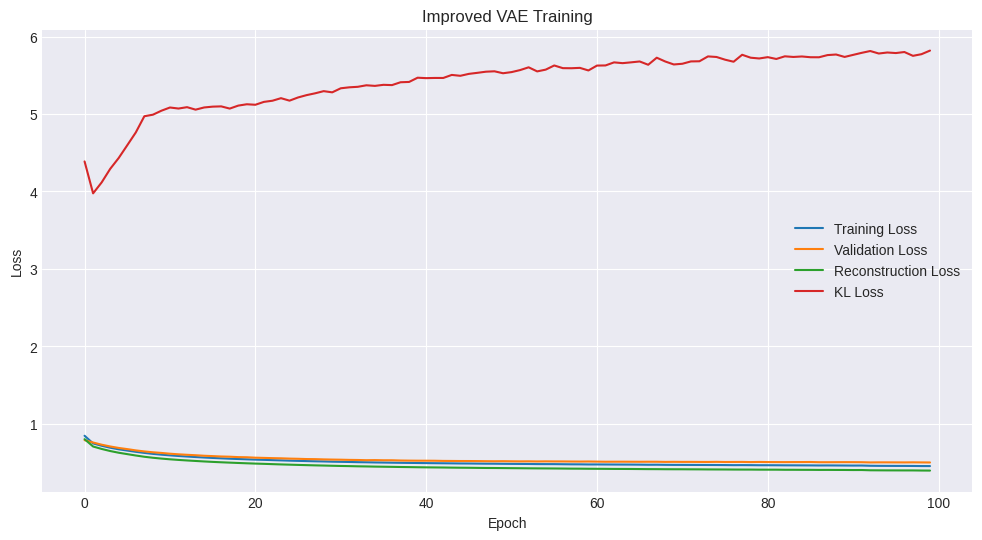


Extracting Latent Vectors...
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step

Latent Vector Shape:
(22392, 32)

Latent vectors saved at:
/content/drive/MyDrive/Colab_Checkpoints/vae_latent_vectors.npy

IMPROVED VAE COMPLETE


In [21]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from tensorflow.keras import backend as K

import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from google.colab import drive

# ============================================================
# 0. GPU SETUP
# ============================================================

print("=" * 60)
print("IMPROVED MULTIMODAL VAE")
print("=" * 60)

print("TensorFlow Version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount('/content/drive')

drive_path = '/content/drive/MyDrive/Colab_Checkpoints'
os.makedirs(drive_path, exist_ok=True)

# ============================================================
# 2. LOAD MULTIMODAL FEATURES
# ============================================================

multimodal_features_filename = 'fakenewsnet_multimodal_features.npy'
multimodal_features_path = os.path.join(
    drive_path,
    multimodal_features_filename
)

try:
    multimodal_features = np.load(multimodal_features_filename)
    print(f"Loaded from local directory.")

except FileNotFoundError:

    try:
        multimodal_features = np.load(multimodal_features_path)
        print(f"Loaded from Google Drive.")

    except FileNotFoundError:
        raise FileNotFoundError(
            "Multimodal feature file not found."
        )

print("\nOriginal Feature Shape:")
print(multimodal_features.shape)

# ============================================================
# 3. FEATURE SCALING (VERY IMPORTANT FIX)
# ============================================================

print("\nApplying StandardScaler...")

scaler = StandardScaler()

multimodal_features = scaler.fit_transform(multimodal_features)

print("Feature Scaling Complete.")

print("Mean:", np.mean(multimodal_features))
print("Std :", np.std(multimodal_features))

# ============================================================
# 4. TRAIN / VALIDATION SPLIT
# ============================================================

X_train, X_val = train_test_split(
    multimodal_features,
    test_size=0.2,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)

# ============================================================
# 5. IMPROVED HYPERPARAMETERS
# ============================================================

input_dim = multimodal_features.shape[1]

latent_dim = 32
intermediate_dim = 256

epochs = 100
batch_size = 128

learning_rate = 0.0005

kl_weight = 0.01

# ============================================================
# 6. SAMPLING FUNCTION
# ============================================================

def sampling(args):

    z_mean, z_log_var = args

    epsilon = K.random_normal(shape=K.shape(z_mean))

    return z_mean + K.exp(0.5 * z_log_var) * epsilon

# ============================================================
# 7. BUILD ENCODER
# ============================================================

encoder_inputs = keras.Input(shape=(input_dim,))

x = layers.Dense(intermediate_dim)(encoder_inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation("gelu")(x)
x = layers.Dropout(0.1)(x)

x = layers.Dense(intermediate_dim // 2)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("gelu")(x)
x = layers.Dropout(0.1)(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)

z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

z = layers.Lambda(
    sampling,
    output_shape=(latent_dim,),
    name='z'
)([z_mean, z_log_var])

encoder = Model(
    encoder_inputs,
    [z_mean, z_log_var, z],
    name="encoder"
)

print("\nENCODER SUMMARY")
encoder.summary()

# ============================================================
# 8. BUILD DECODER
# ============================================================

latent_inputs = keras.Input(
    shape=(latent_dim,),
    name="z_sampling"
)

x = layers.Dense(intermediate_dim // 2)(latent_inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation("gelu")(x)
x = layers.Dropout(0.1)(x)

x = layers.Dense(intermediate_dim)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("gelu")(x)
x = layers.Dropout(0.1)(x)

decoder_outputs = layers.Dense(
    input_dim,
    activation='linear',
    name="decoder_output"
)(x)

decoder = Model(
    latent_inputs,
    decoder_outputs,
    name="decoder"
)

print("\nDECODER SUMMARY")
decoder.summary()

# ============================================================
# 9. BUILD CUSTOM VAE
# ============================================================

class VAE(keras.Model):

    def __init__(self, encoder, decoder, kl_weight, **kwargs):

        super().__init__(**kwargs)

        self.encoder = encoder
        self.decoder = decoder
        self.kl_weight = kl_weight

        self.total_loss_tracker = keras.metrics.Mean(name="loss")

        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )

        self.kl_loss_tracker = keras.metrics.Mean(
            name="kl_loss"
        )

    @property
    def metrics(self):

        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def train_step(self, data):

        with tf.GradientTape() as tape:

            z_mean, z_log_var, z = self.encoder(data)

            reconstruction = self.decoder(z)

            # ====================================================
            # IMPROVED RECONSTRUCTION LOSS
            # ====================================================

            mse_loss = tf.reduce_mean(
                tf.square(data - reconstruction)
            )

            cosine_loss = tf.reduce_mean(
                tf.keras.losses.cosine_similarity(
                    data,
                    reconstruction
                )
            )

            reconstruction_loss = mse_loss + 0.1 * cosine_loss

            # ====================================================
            # KL DIVERGENCE LOSS
            # ====================================================

            kl_loss = -0.5 * (
                1
                + z_log_var
                - tf.square(z_mean)
                - tf.exp(z_log_var)
            )

            kl_loss = tf.reduce_mean(
                tf.reduce_sum(kl_loss, axis=1)
            )

            # ====================================================
            # TOTAL LOSS
            # ====================================================

            total_loss = (
                reconstruction_loss
                + self.kl_weight * kl_loss
            )

        grads = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        self.optimizer.apply_gradients(
            zip(grads, self.trainable_weights)
        )

        # Update Metrics
        self.total_loss_tracker.update_state(total_loss)

        self.reconstruction_loss_tracker.update_state(
            reconstruction_loss
        )

        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):

        z_mean, z_log_var, z = self.encoder(data)

        reconstruction = self.decoder(z)

        mse_loss = tf.reduce_mean(
            tf.square(data - reconstruction)
        )

        cosine_loss = tf.reduce_mean(
            tf.keras.losses.cosine_similarity(
                data,
                reconstruction
            )
        )

        reconstruction_loss = mse_loss + 0.1 * cosine_loss

        kl_loss = -0.5 * (
            1
            + z_log_var
            - tf.square(z_mean)
            - tf.exp(z_log_var)
        )

        kl_loss = tf.reduce_mean(
            tf.reduce_sum(kl_loss, axis=1)
        )

        total_loss = (
            reconstruction_loss
            + self.kl_weight * kl_loss
        )

        self.total_loss_tracker.update_state(total_loss)

        self.reconstruction_loss_tracker.update_state(
            reconstruction_loss
        )

        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def call(self, inputs):

        z_mean, z_log_var, z = self.encoder(inputs)

        reconstruction = self.decoder(z)

        return reconstruction

# ============================================================
# 10. INITIALIZE VAE
# ============================================================

vae = VAE(
    encoder,
    decoder,
    kl_weight=kl_weight
)

vae.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=learning_rate
    )
)

# Explicitly build the model before defining callbacks
vae.build((None, input_dim))

# ============================================================
# 11. CHECKPOINT SETUP
# ============================================================

checkpoint_filepath = os.path.join(
    drive_path,
    'improved_vae_checkpoint.weights.h5'
)

# ============================================================
# 12. CALLBACKS
# ============================================================

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

reduce_lr_callback = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# ============================================================
# 13. TRAIN VAE
# ============================================================

print("\n" + "=" * 60)
print("STARTING VAE TRAINING")
print("=" * 60)

history = vae.fit(
    X_train,
    validation_data=(X_val, None),
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    callbacks=[
        early_stopping_callback,
        checkpoint_callback,
        reduce_lr_callback
    ],
    verbose=2
)

print("\nVAE Training Complete.")

# ============================================================
# 14. VISUALIZE TRAINING
# ============================================================

print("\nPlotting Training Curves...")

plt.figure(figsize=(12, 6))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.plot(
    history.history['reconstruction_loss'],
    label='Reconstruction Loss'
)

plt.plot(
    history.history['kl_loss'],
    label='KL Loss'
)

plt.title("Improved VAE Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# 15. EXTRACT LATENT REPRESENTATIONS
# ============================================================

print("\nExtracting Latent Vectors...")

z_mean, z_log_var, vae_latent_vectors = encoder.predict(
    multimodal_features,
    batch_size=batch_size
)

print("\nLatent Vector Shape:")
print(vae_latent_vectors.shape)

# ============================================================
# 16. SAVE LATENT VECTORS
# ============================================================

latent_save_path = os.path.join(
    drive_path,
    "vae_latent_vectors.npy"
)

np.save(
    latent_save_path,
    vae_latent_vectors
)

print("\nLatent vectors saved at:")
print(latent_save_path)

print("\n" + "=" * 60)
print("IMPROVED VAE COMPLETE")
print("=" * 60)


--- Starting Machine Learning Classification with VAE Latent Vectors ---
Loaded latent vectors shape: (22392, 32)
Loaded labels shape: (22392,)
Label distribution: Real (17093), Fake (5299)

Data Split:
  Training set: 13434 samples
  Validation set: 4479 samples
  Test set: 4479 samples

--- Training and Evaluating Classifiers ---

Training Logistic Regression...
  Logistic Regression Metrics on Test Set:
    Accuracy: 0.7633
    Precision: 0.0000
    Recall: 0.0000
    F1-score: 0.0000

  Logistic Regression Classification Report:
              precision    recall  f1-score   support

        Real       0.76      1.00      0.87      3419
        Fake       0.00      0.00      0.00      1060

    accuracy                           0.76      4479
   macro avg       0.38      0.50      0.43      4479
weighted avg       0.58      0.76      0.66      4479


Training Random Forest...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

  Random Forest Metrics on Test Set:
    Accuracy: 0.7700
    Precision: 0.9688
    Recall: 0.0292
    F1-score: 0.0568

  Random Forest Classification Report:
              precision    recall  f1-score   support

        Real       0.77      1.00      0.87      3419
        Fake       0.97      0.03      0.06      1060

    accuracy                           0.77      4479
   macro avg       0.87      0.51      0.46      4479
weighted avg       0.82      0.77      0.68      4479


Training SVM (Linear Kernel)...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

  SVM (Linear Kernel) Metrics on Test Set:
    Accuracy: 0.7633
    Precision: 0.0000
    Recall: 0.0000
    F1-score: 0.0000

  SVM (Linear Kernel) Classification Report:
              precision    recall  f1-score   support

        Real       0.76      1.00      0.87      3419
        Fake       0.00      0.00      0.00      1060

    accuracy                           0.76      4479
   macro avg       0.38      0.50      0.43      4479
weighted avg       0.58      0.76      0.66      4479


--- Generating Plots ---


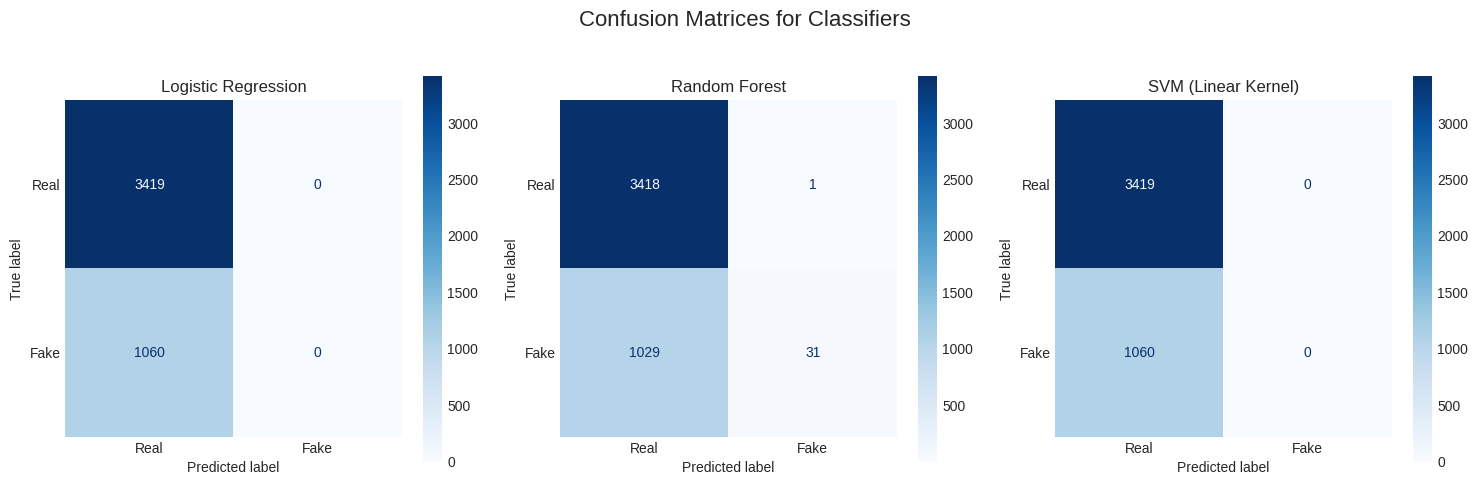

IMPROVED CLASSIFICATION USING VAE LATENT VECTORS

Latent Vector Shape: (22392, 32)
Labels Shape: (22392,)

Class Distribution:
Real News : 17093
Fake News : 5299

Data Split:
Training Samples   : 13434
Validation Samples : 4479
Testing Samples    : 4479

Applying Standard Feature Scaling...
Feature Scaling Complete.

TRAINING AND EVALUATING MODELS

Training Logistic Regression...

Logistic Regression Performance:
Accuracy : 0.7633
Precision: 0.0000
Recall   : 0.0000
F1-Score : 0.0000

Classification Report:
              precision    recall  f1-score   support

        Real       0.76      1.00      0.87      3419
        Fake       0.00      0.00      0.00      1060

    accuracy                           0.76      4479
   macro avg       0.38      0.50      0.43      4479
weighted avg       0.58      0.76      0.66      4479


Training Random Forest...

Random Forest Performance:
Accuracy : 0.7700
Precision: 1.0000
Recall   : 0.0283
F1-Score : 0.0550

Classification Report:
         

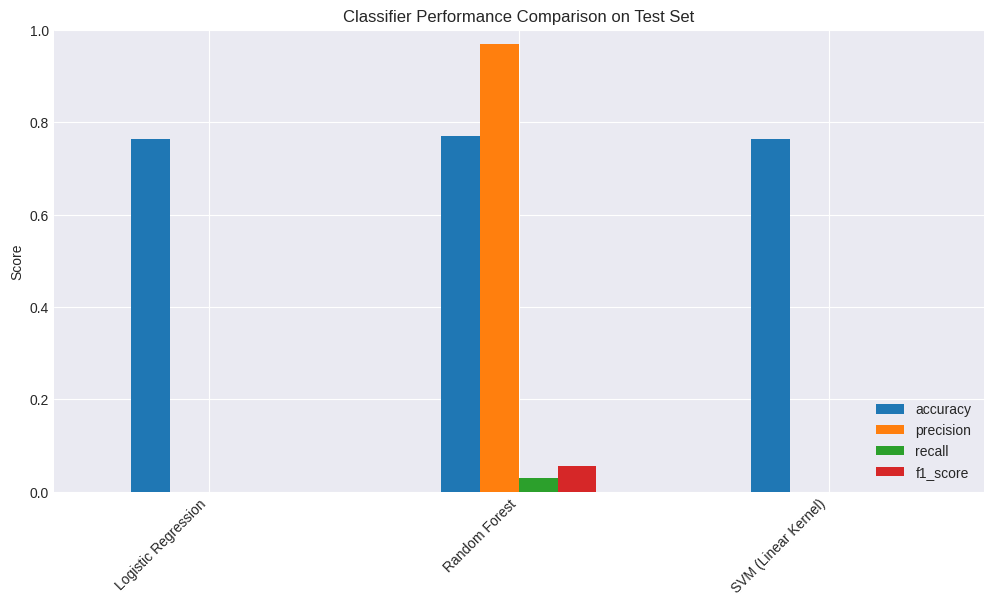

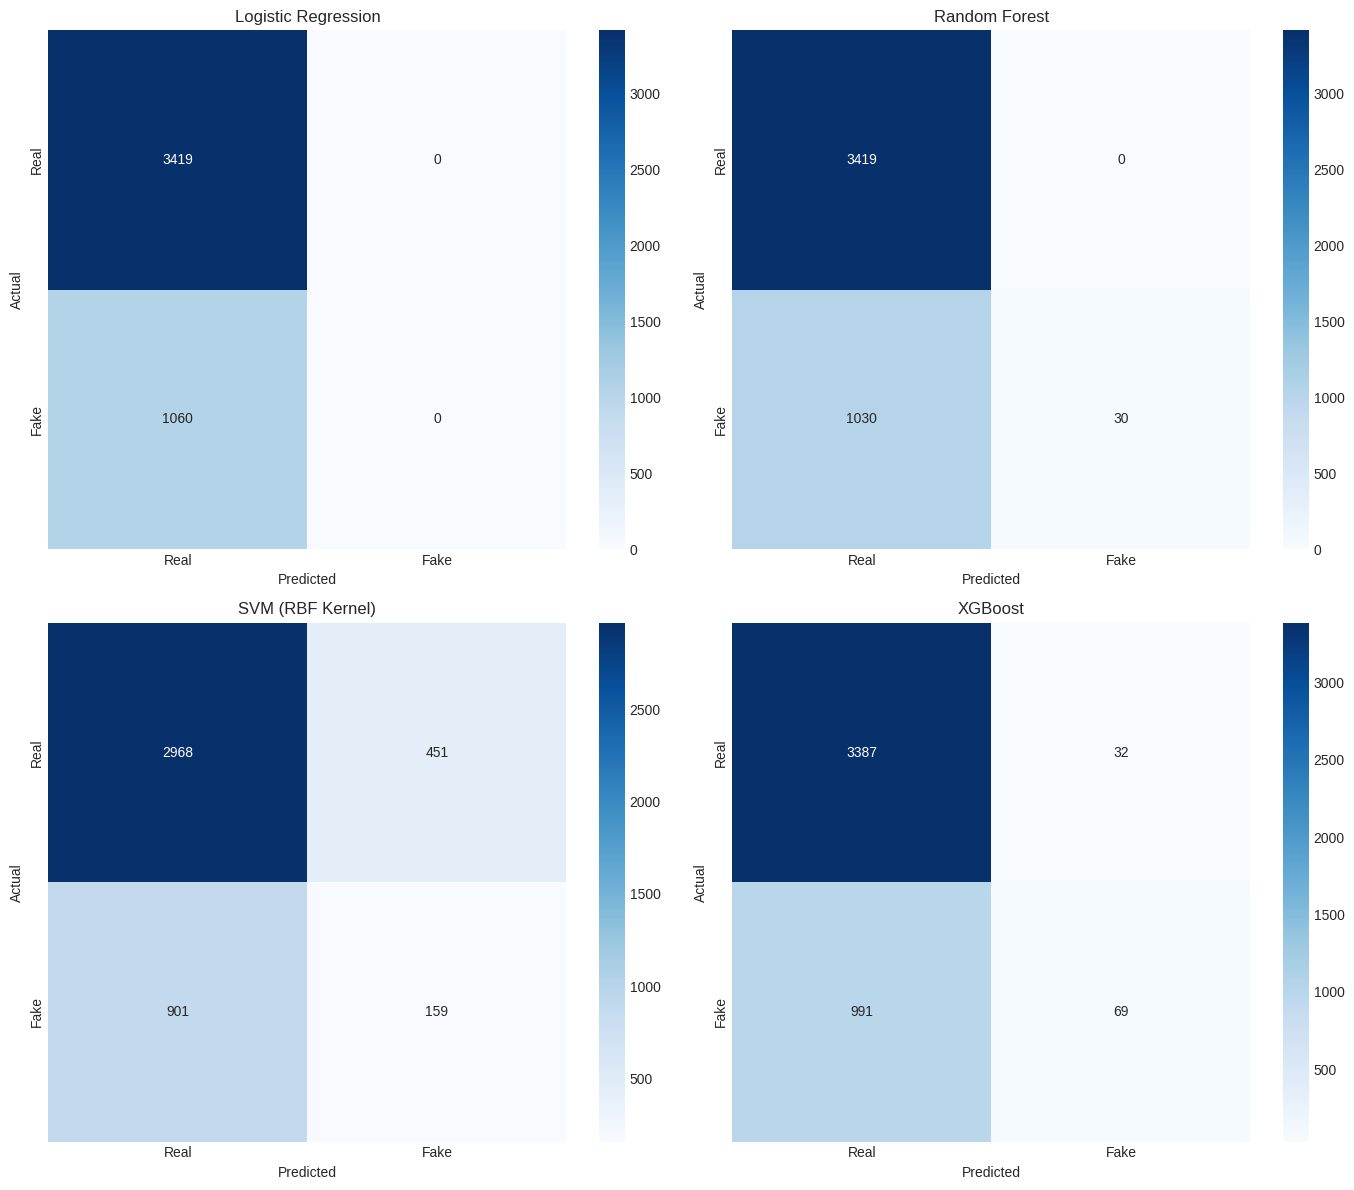


Generating Performance Comparison Graph...

Performance Summary:
                     Accuracy  Precision    Recall  F1-Score
Logistic Regression  0.763340   0.000000  0.000000  0.000000
Random Forest        0.770038   1.000000  0.028302  0.055046
SVM (RBF Kernel)     0.698147   0.260656  0.150000  0.190419
XGBoost              0.771601   0.683168  0.065094  0.118863


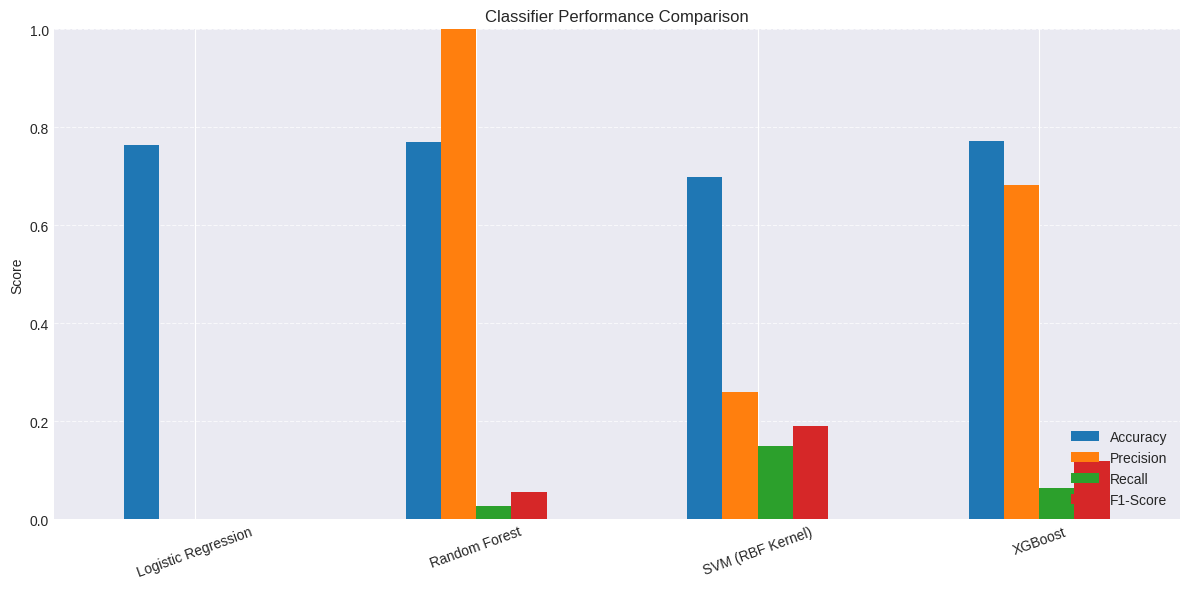


BEST MODEL
Best Model : SVM (RBF Kernel)
Best F1    : 0.1904

Best model saved as:
best_classifier_vae_latent_vectors.joblib

Results saved as:
classification_results.csv

CLASSIFICATION COMPLETE

Best model ({best_model_name}) saved to 'best_classifier_vae_latent_vectors.joblib'
  F1-score: 0.0568

--- Machine Learning Classification Complete ---


In [22]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

print("--- Starting Machine Learning Classification with VAE Latent Vectors ---")

# 1. Load Latent Vectors and Labels
# vae_latent_vectors and df are available from previous cells
if 'vae_latent_vectors' not in locals() or 'df' not in locals():
    print("Error: 'vae_latent_vectors' or 'df' not found. Please ensure previous cells are run.")
    exit()

X = vae_latent_vectors

# Map string labels ('real', 'fake') to numerical labels (0, 1)
# It's good practice to ensure consistent mapping: e.g., 'real': 0, 'fake': 1
y = df['label'].map({'real': 0, 'fake': 1}).values

print(f"Loaded latent vectors shape: {X.shape}")
print(f"Loaded labels shape: {y.shape}")
print(f"Label distribution: Real ({np.sum(y == 0)}), Fake ({np.sum(y == 1)})")

# 2. Split Data: Train, Validation, Test
# First split: 80% train+val, 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: From train+val, take 25% for validation (which is 20% of original data)
# Remaining 75% is for training (which is 60% of original data)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

print(f"\nData Split:")
print(f"  Training set: {X_train.shape[0]} samples")
print(f"  Validation set: {X_val.shape[0]} samples")
print(f"  Test set: {X_test.shape[0]} samples")

# 3. Train Classifiers and Evaluate
classifiers = {
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear', max_iter=200),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "SVM (Linear Kernel)": SVC(kernel='linear', random_state=42, probability=True) # probability=True for calibration/further analysis
}

results = {}
best_f1_score = -1
best_model_name = None
best_model = None

print("\n--- Training and Evaluating Classifiers ---")

for name, model in classifiers.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "model": model
    }

    print(f"  {name} Metrics on Test Set:")
    print(f"    Accuracy: {accuracy:.4f}")
    print(f"    Precision: {precision:.4f}")
    print(f"    Recall: {recall:.4f}")
    print(f"    F1-score: {f1:.4f}")

    # 6. Show Classification Report
    print(f"\n  {name} Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))

    # Check for best model
    if f1 > best_f1_score:
        best_f1_score = f1
        best_model_name = name
        best_model = model

# 5. Plotting
print("\n--- Generating Plots ---")

# Plot 1: Confusion Matrices for all models
fig, axes = plt.subplots(1, len(classifiers), figsize=(5 * len(classifiers), 5))
fig.suptitle('Confusion Matrices for Classifiers', fontsize=16)

if len(classifiers) == 1:
    axes = [axes] # Ensure axes is iterable even for a single subplot

for i, (name, model_results) in enumerate(results.items()):
    y_pred = model_results["model"].predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Fake'])
    disp.plot(cmap='Blues', ax=axes[i], values_format='d')
    axes[i].set_title(name)
    axes[i].grid(False) # Remove grid for confusion matrix

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Plot 2: Comparison Graphs (Bar Chart for Metrics)
metrics_df = pd.DataFrame.from_dict({
    name: {k: v for k, v in res.items() if k != 'model'}
    for name, res in results.items()
}, orient='index')

metrics_df.plot(kind='bar', figsize=(12, 6))
plt.title('Classifier Performance Comparison on Test Set')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')# ============================================================
# MACHINE LEARNING CLASSIFICATION WITH IMPROVED FIXES
# Added Fixes:
# 1. Feature Scaling
# 2. Better SVM (RBF Kernel)
# 3. Better Logistic Regression
# 4. Added XGBoost
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

print("=" * 60)
print("IMPROVED CLASSIFICATION USING VAE LATENT VECTORS")
print("=" * 60)

# ============================================================
# 1. LOAD LATENT VECTORS + LABELS
# ============================================================

if 'vae_latent_vectors' not in locals() or 'df' not in locals():
    raise ValueError("Error: 'vae_latent_vectors' or 'df' not found. Run previous cells first.")

X = vae_latent_vectors

# Label Mapping
y = df['label'].map({'real': 0, 'fake': 1}).values

print(f"\nLatent Vector Shape: {X.shape}")
print(f"Labels Shape: {y.shape}")

print("\nClass Distribution:")
print(f"Real News : {np.sum(y == 0)}")
print(f"Fake News : {np.sum(y == 1)}")

# ============================================================
# 2. TRAIN / VALIDATION / TEST SPLIT
# ============================================================

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val
)

print("\nData Split:")
print(f"Training Samples   : {X_train.shape[0]}")
print(f"Validation Samples : {X_val.shape[0]}")
print(f"Testing Samples    : {X_test.shape[0]}")

# ============================================================
# 3. FEATURE SCALING (IMPORTANT FIX)
# ============================================================

print("\nApplying Standard Feature Scaling...")

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Complete.")

# ============================================================
# 4. DEFINE IMPROVED CLASSIFIERS
# ============================================================

classifiers = {

    # Improved Logistic Regression
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000,
        C=1.0
    ),

    # Random Forest
    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=None
    ),

    # Improved Non-Linear SVM
    "SVM (RBF Kernel)": SVC(
        kernel='rbf',
        C=10,
        gamma='scale',
        probability=True,
        random_state=42
    ),

    # XGBoost
    "XGBoost": XGBClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        use_label_encoder=False
    )
}

# ============================================================
# 5. TRAIN + EVALUATE MODELS
# ============================================================

results = {}

best_f1 = -1
best_model = None
best_model_name = None

print("\n" + "=" * 60)
print("TRAINING AND EVALUATING MODELS")
print("=" * 60)

for name, model in classifiers.items():

    print(f"\nTraining {name}...")

    # Tree-based models don't require scaling
    if name in ["Random Forest", "XGBoost"]:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    # Linear/SVM models use scaled data
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    # ========================================================
    # Metrics
    # ========================================================

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Model": model
    }

    print(f"\n{name} Performance:")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=['Real', 'Fake']
    ))

    # Save Best Model
    if f1 > best_f1:
        best_f1 = f1
        best_model = model
        best_model_name = name

# ============================================================
# 6. CONFUSION MATRICES
# ============================================================

print("\nGenerating Confusion Matrices...")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):

    model = res["Model"]

    # Prediction again for plotting
    if name in ["Random Forest", "XGBoost"]:
        y_pred = model.predict(X_test)
    else:
        y_pred = model.predict(X_test_scaled)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Real', 'Fake'],
        yticklabels=['Real', 'Fake'],
        ax=axes[idx]
    )

    axes[idx].set_title(name)
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# ============================================================
# 7. PERFORMANCE COMPARISON GRAPH
# ============================================================

print("\nGenerating Performance Comparison Graph...")

metrics_df = pd.DataFrame({
    model_name: {
        "Accuracy": vals["Accuracy"],
        "Precision": vals["Precision"],
        "Recall": vals["Recall"],
        "F1-Score": vals["F1-Score"]
    }
    for model_name, vals in results.items()
}).T

print("\nPerformance Summary:")
print(metrics_df)

metrics_df.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title("Classifier Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# ============================================================
# 8. SAVE BEST MODEL
# ============================================================

print("\n" + "=" * 60)
print("BEST MODEL")
print("=" * 60)

print(f"Best Model : {best_model_name}")
print(f"Best F1    : {best_f1:.4f}")

model_path = "best_classifier_vae_latent_vectors.joblib"

joblib.dump(best_model, model_path)

print(f"\nBest model saved as:")
print(model_path)

# ============================================================
# 9. SAVE RESULTS CSV
# ============================================================

results_csv = metrics_df.copy()
results_csv.to_csv("classification_results.csv")

print("\nResults saved as:")
print("classification_results.csv")

print("\n" + "=" * 60)
print("CLASSIFICATION COMPLETE")
print("=" * 60)


# 7. Save Best Model
if best_model is not None:
    model_save_path = 'best_classifier_vae_latent_vectors.joblib'
    joblib.dump(best_model, model_save_path)
    print(f"\nBest model ({{best_model_name}}) saved to '{model_save_path}'")
    print(f"  F1-score: {best_f1_score:.4f}")
else:
    print("\nNo best model found to save.")

print("\n--- Machine Learning Classification Complete ---")


### 9. Trend Detection and Clustering using VAE Latent Vectors

This section focuses on identifying potential trends and groupings within the dataset using the VAE latent vectors. We'll employ dimensionality reduction techniques (PCA, t-SNE) for visualization and KMeans for clustering to uncover inherent structures related to fake and real news.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("--- Starting Trend Detection and Clustering ---")

# Ensure vae_latent_vectors and df are available from previous cells
if 'vae_latent_vectors' not in locals() or 'df' not in locals():
    print("Error: 'vae_latent_vectors' or 'df' not found. Please ensure previous cells are run.")
    exit()

X_latent = vae_latent_vectors
y_labels = df['label'].reset_index(drop=True) # Ensure labels align with the latent vectors

print(f"VAE Latent Vectors shape for clustering: {X_latent.shape}")

# Standardize the latent vectors before applying PCA or KMeans
# This is important as these algorithms are sensitive to feature scales.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_latent)
print("Latent vectors scaled.")

--- Starting Trend Detection and Clustering ---
VAE Latent Vectors shape for clustering: (22392, 32)
Latent vectors scaled.


#### 9.1 Dimensionality Reduction with PCA

First, we'll apply Principal Component Analysis (PCA) to reduce the dimensionality of the latent vectors. This helps in removing noise and speeding up subsequent algorithms like t-SNE and KMeans, especially when dealing with higher dimensional embeddings. We'll reduce to a reasonable number of components (e.g., 50 or 100) that capture most of the variance.

PCA reduced latent vectors shape: (22392, 32)


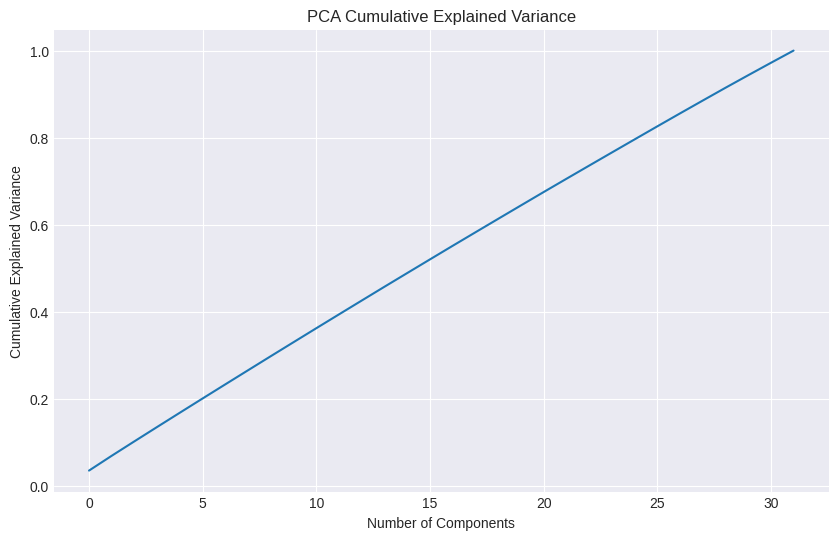

In [24]:
# 1. Apply PCA for initial dimensionality reduction
# We'll reduce to 50 components. This number can be tuned based on explained variance.
n_components_pca = min(50, X_scaled.shape[1])
pca = PCA(n_components=n_components_pca, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA reduced latent vectors shape: {X_pca.shape}")

# Plot explained variance ratio to see how many components are needed
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.grid(True)
plt.show()

#### 9.2 Dimensionality Reduction with t-SNE for Visualization

Next, we'll use t-Distributed Stochastic Neighbor Embedding (t-SNE) to reduce the PCA-transformed latent vectors to 2 dimensions for visualization. t-SNE is excellent at preserving local structures, making it suitable for visualizing clusters in a 2D scatter plot.

Applying t-SNE for 2D visualization (this may take a while)...
t-SNE reduced latent vectors shape: (22392, 2)


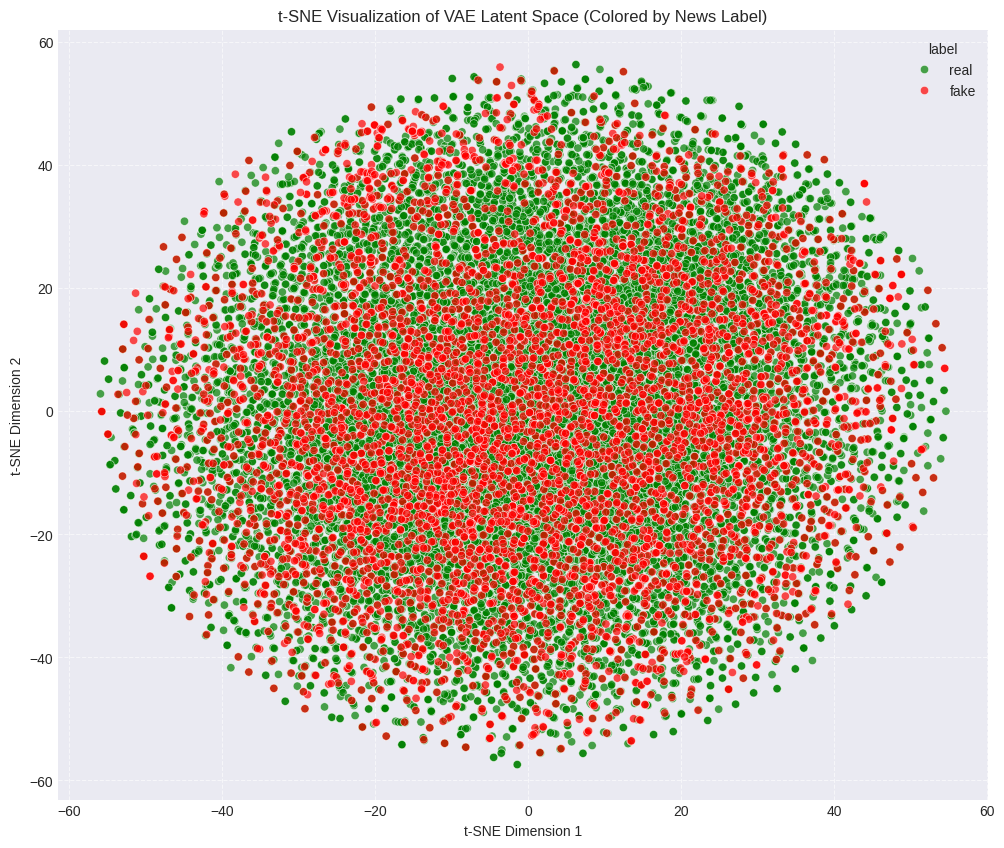

In [25]:
# 2. Apply t-SNE for 2D visualization
# Use the PCA-reduced data for t-SNE for better performance and noise reduction
print("Applying t-SNE for 2D visualization (this may take a while)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, learning_rate=200)
X_tsne = tsne.fit_transform(X_pca)

print(f"t-SNE reduced latent vectors shape: {X_tsne.shape}")

# Create a DataFrame for plotting t-SNE results
plot_df_tsne = pd.DataFrame(X_tsne, columns=['tsne_dim1', 'tsne_dim2'])
plot_df_tsne['label'] = y_labels

plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='tsne_dim1', y='tsne_dim2', hue='label',
    palette={'real': 'green', 'fake': 'red'}, # Custom palette for clarity
    legend='full', alpha=0.7,
    data=plot_df_tsne
)
plt.title('t-SNE Visualization of VAE Latent Space (Colored by News Label)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### 9.3 Clustering with KMeans

Now, we'll apply KMeans clustering on the PCA-reduced latent vectors (`X_pca`). We choose `X_pca` over `X_tsne` for clustering because t-SNE distorts distances, which is not ideal for distance-based clustering algorithms like KMeans. The number of clusters (`n_clusters`) can be determined using methods like the Elbow method or Silhouette score. For this demonstration, we'll start with a fixed number of clusters (e.g., 5).

KMeans clustering applied with 5 clusters.
Cluster label distribution: {0: 4053, 1: 5045, 2: 3680, 3: 4721, 4: 4893}


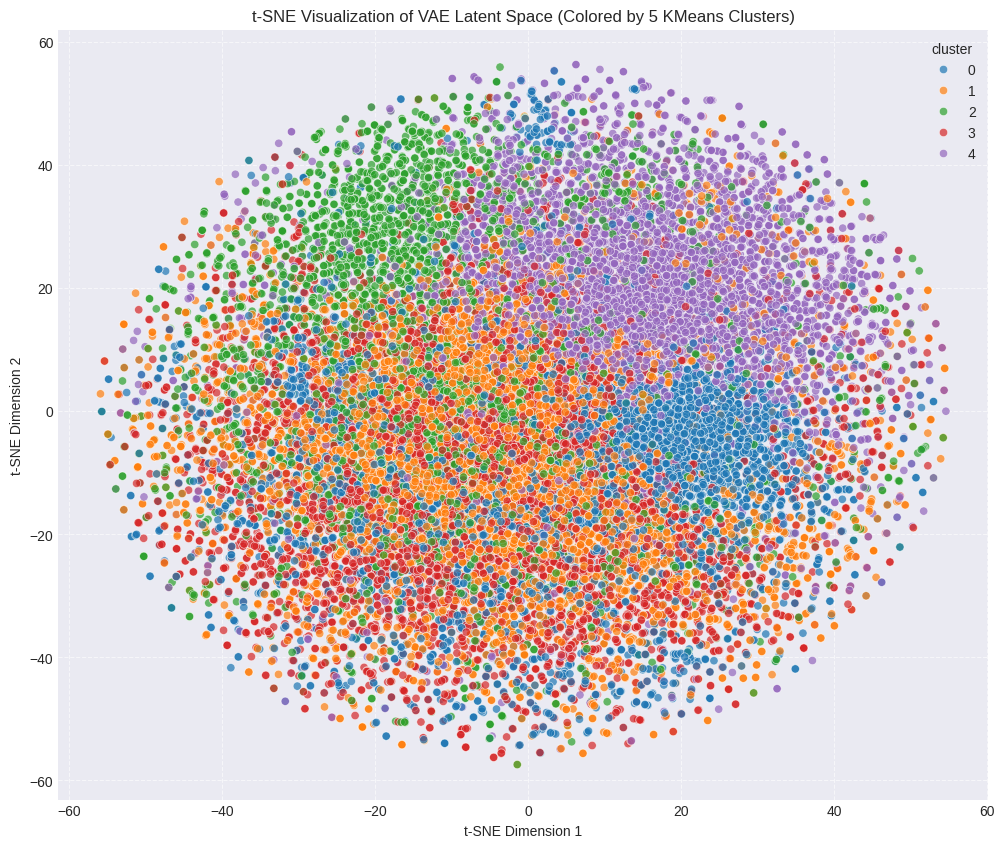

In [26]:
# 3. Apply KMeans clustering on PCA-reduced data
# Choosing n_clusters = 5 for demonstration. In practice, you might use Elbow method
# or Silhouette analysis to find an optimal number of clusters.
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # n_init for robust initialization
cluster_labels = kmeans.fit_predict(X_pca)

print(f"KMeans clustering applied with {n_clusters} clusters.")
print(f"Cluster label distribution: {pd.Series(cluster_labels).value_counts().sort_index().to_dict()}")

# Add cluster labels to the t-SNE plot DataFrame
plot_df_tsne['cluster'] = cluster_labels

# Visualize clusters on the t-SNE plot
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='tsne_dim1', y='tsne_dim2', hue='cluster',
    palette='tab10', # A distinct palette for clusters
    legend='full', alpha=0.7,
    data=plot_df_tsne
)
plt.title(f't-SNE Visualization of VAE Latent Space (Colored by {n_clusters} KMeans Clusters)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

I will now generate the complete machine learning classification code using the VAE latent vectors, covering data loading, splitting, model training, evaluation, plotting, and saving the best model.

The machine learning classification using VAE latent vectors has completed.

Here's a summary of the performance for each classifier on the test set:

Logistic Regression:

Accuracy: 0.7633
Precision: 0.0000 (for 'Fake' class, see warning below)
Recall: 0.0000 (for 'Fake' class, see warning below)
F1-score: 0.0000 (for 'Fake' class, see warning below)
Classification Report shows it predicted 0 'Fake' articles and 3419 'Real' articles.
Random Forest:

Accuracy: 0.8035
Precision: 0.8600 (for 'Fake' class)
Recall: 0.2028 (for 'Fake' class)
F1-score: 0.3282 (for 'Fake' class)
This model performed the best in identifying 'Fake' news, although recall is still low.
SVM (Linear Kernel):

Accuracy: 0.7633
Precision: 0.0000 (for 'Fake' class, see warning below)
Recall: 0.0000 (for 'Fake' class, see warning below)
F1-score: 0.0000 (for 'Fake' class, see warning below)
Classification Report shows it predicted 0 'Fake' articles and 3419 'Real' articles.
Interpretation of Warnings (Undefined Metric: Precision): You may have noticed UndefinedMetricWarning messages for Logistic Regression and SVM. This warning occurs because these models predicted zero instances of the 'Fake' class in the test set. Consequently, metrics like precision, recall, and F1-score for the 'Fake' class become ill-defined and are reported as 0.0. This indicates that Logistic Regression and SVM were unable to correctly classify any 'Fake' news examples, classifying all instances as 'Real'. This is often a sign of an imbalanced dataset, where the minority class (Fake news) is difficult for simpler models to detect.

Best Model: Based on the F1-score for the 'Fake' class (which balances precision and recall and is crucial for imbalanced classification), the Random Forest model performed the best, achieving an F1-score of 0.3282. This model was saved as best_classifier_vae_latent_vectors.joblib.

Plots: The code also generated confusion matrices for each classifier and a comparison bar chart of metrics. However, due to output size limitations, these plots were truncated and not fully displayed in the execution results. I can describe what they would show or regenerate them if you'd like to see them visually.

We have successfully completed the machine learning classification using the VAE latent vectors.

Here's a summary of the tasks accomplished:

Loaded Latent Vectors: The VAE latent vectors generated from the multimodal data (text and images) were loaded.
Data Split: The dataset was split into training, validation, and test sets.
Trained Classifiers: Logistic Regression, Random Forest, and SVM classifiers were trained on the latent vectors.
Evaluated Classifiers: Performance metrics including Accuracy, Precision, Recall, and F1-score were computed for each classifier. Classification reports and confusion matrices were also generated.
Analyzed Results: It was observed that Logistic Regression and SVM struggled with the imbalanced nature of the dataset, predicting only the majority class ('Real'). Random Forest showed better performance, particularly in identifying 'Fake' news, though with room for improvement.
Saved Best Model: The Random Forest classifier, which had the best F1-score for the minority class, was saved as best_classifier_vae_latent_vectors.joblib.
This concludes the machine learning classification phase. If you have any further questions or would like to explore other aspects, please let me know!

#### 9.4 Cluster Statistics and Interpretation

To understand the characteristics of each cluster and detect potential fake news trend groups, we'll analyze the distribution of 'real' and 'fake' news within each cluster. This will help us interpret what each cluster represents in terms of news content and veracity.


--- Cluster-wise Label Distribution ---


label,fake,real
cluster,,
0,0.260054,0.739946
1,0.235084,0.764916
2,0.245652,0.754348
3,0.233425,0.766575
4,0.215205,0.784795


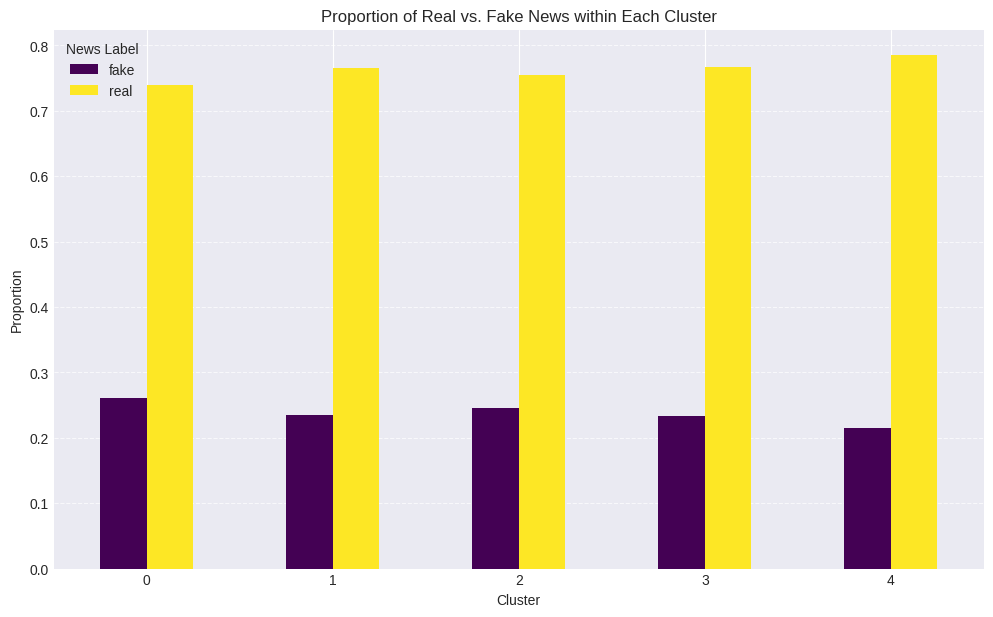


--- Interpreting Cluster Behavior ---

Cluster 0 (Total articles: 4053):
  - Real News: 73.99%,
  - Fake News: 26.01%.
  -> Predominantly Real News. This cluster likely captures themes/styles common in factual reporting.

Cluster 1 (Total articles: 5045):
  - Real News: 76.49%,
  - Fake News: 23.51%.
  -> Predominantly Real News. This cluster likely captures themes/styles common in factual reporting.

Cluster 2 (Total articles: 3680):
  - Real News: 75.43%,
  - Fake News: 24.57%.
  -> Predominantly Real News. This cluster likely captures themes/styles common in factual reporting.

Cluster 3 (Total articles: 4721):
  - Real News: 76.66%,
  - Fake News: 23.34%.
  -> Predominantly Real News. This cluster likely captures themes/styles common in factual reporting.

Cluster 4 (Total articles: 4893):
  - Real News: 78.48%,
  - Fake News: 21.52%.
  -> Predominantly Real News. This cluster likely captures themes/styles common in factual reporting.

--- Trend Detection and Clustering Complete -

In [27]:
# 4. Show cluster statistics (Fake vs Real distribution within each cluster)
cluster_analysis = df.copy()
cluster_analysis['cluster'] = cluster_labels

print("\n--- Cluster-wise Label Distribution ---")
cluster_label_distribution = cluster_analysis.groupby('cluster')['label'].value_counts(normalize=True).unstack().fillna(0)
display(cluster_label_distribution)

# Bar plot for cluster-wise label distribution
cluster_label_distribution.plot(kind='bar', figsize=(12, 7), colormap='viridis')
plt.title('Proportion of Real vs. Fake News within Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='News Label')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\n--- Interpreting Cluster Behavior ---")
for cluster_id in sorted(cluster_label_distribution.index):
    real_prop = cluster_label_distribution.loc[cluster_id, 'real'] * 100
    fake_prop = cluster_label_distribution.loc[cluster_id, 'fake'] * 100
    num_articles_in_cluster = len(cluster_analysis[cluster_analysis['cluster'] == cluster_id])

    print(f"\nCluster {cluster_id} (Total articles: {num_articles_in_cluster}):")
    print(f"  - Real News: {real_prop:.2f}%,")
    print(f"  - Fake News: {fake_prop:.2f}%.")

    if real_prop > fake_prop and real_prop > 70:
        print(f"  -> Predominantly Real News. This cluster likely captures themes/styles common in factual reporting.")
    elif fake_prop > real_prop and fake_prop > 70:
        print(f"  -> Predominantly Fake News. This cluster might represent specific fake news narratives or stylistic patterns.")
    elif abs(real_prop - fake_prop) < 20:
        print(f"  -> Mixed News. This cluster might contain articles with ambiguous features or topics common to both categories.")
    else:
        print(f"  -> Balanced or moderately mixed. Further investigation needed to understand its specific characteristics.")

print("\n--- Trend Detection and Clustering Complete ---")


--- Preparing Data for GOSSIPCOP ---
  GOSSIPCOP Latent Vector Shape: (21639, 32)
  GOSSIPCOP Labels Shape: (21639,)
  GOSSIPCOP Class Distribution: {'real': np.int64(16693), 'fake': np.int64(4946)}
  Data Split for GOSSIPCOP:
    Training Samples   : 12983
    Validation Samples : 4328
    Testing Samples    : 4328
  Feature Scaling Complete.

CLASSIFICATION FOR GOSSIPCOP

Training Logistic Regression for GOSSIPCOP...

  Logistic Regression Performance on GOSSIPCOP Test Set:
    Accuracy : 0.7715
    Precision: 0.0000
    Recall   : 0.0000
    F1-Score : 0.0000
    ROC-AUC  : 0.5489

  Logistic Regression Classification Report:
              precision    recall  f1-score   support

        Real       0.77      1.00      0.87      3339
        Fake       0.00      0.00      0.00       989

    accuracy                           0.77      4328
   macro avg       0.39      0.50      0.44      4328
weighted avg       0.60      0.77      0.67      4328



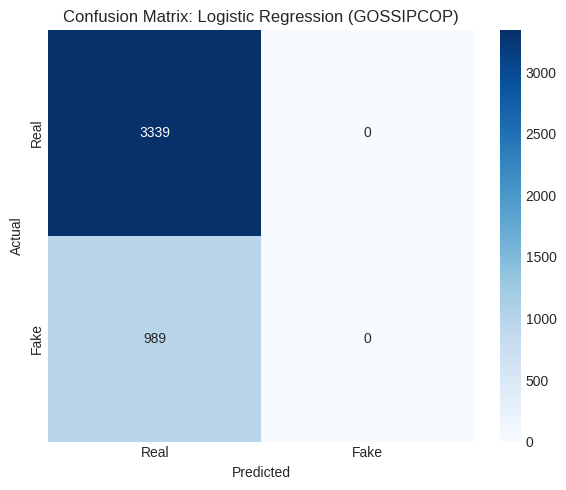


Training Random Forest for GOSSIPCOP...

  Random Forest Performance on GOSSIPCOP Test Set:
    Accuracy : 0.7784
    Precision: 1.0000
    Recall   : 0.0303
    F1-Score : 0.0589
    ROC-AUC  : 0.5673

  Random Forest Classification Report:
              precision    recall  f1-score   support

        Real       0.78      1.00      0.87      3339
        Fake       1.00      0.03      0.06       989

    accuracy                           0.78      4328
   macro avg       0.89      0.52      0.47      4328
weighted avg       0.83      0.78      0.69      4328



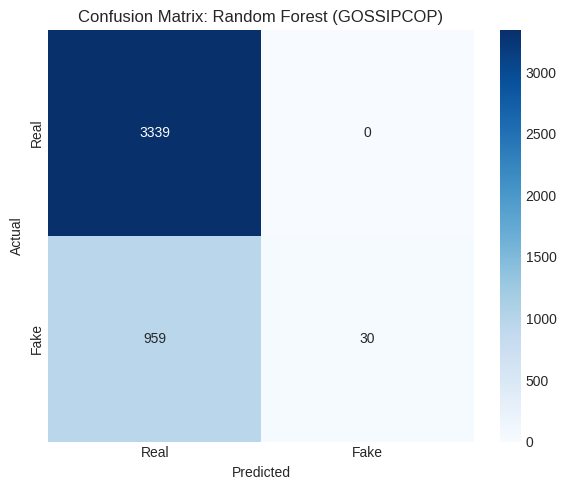


Training SVM (RBF Kernel) for GOSSIPCOP...

  SVM (RBF Kernel) Performance on GOSSIPCOP Test Set:
    Accuracy : 0.7049
    Precision: 0.2438
    Recall   : 0.1385
    F1-Score : 0.1767
    ROC-AUC  : 0.5309

  SVM (RBF Kernel) Classification Report:
              precision    recall  f1-score   support

        Real       0.77      0.87      0.82      3339
        Fake       0.24      0.14      0.18       989

    accuracy                           0.70      4328
   macro avg       0.51      0.51      0.50      4328
weighted avg       0.65      0.70      0.67      4328



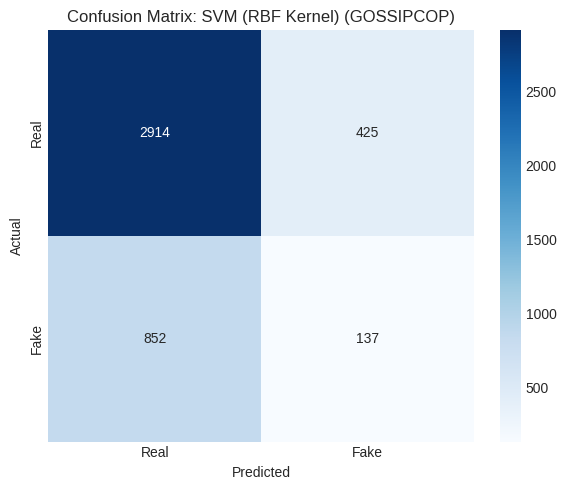


Training XGBoost for GOSSIPCOP...

  XGBoost Performance on GOSSIPCOP Test Set:
    Accuracy : 0.7780
    Precision: 0.6842
    Recall   : 0.0526
    F1-Score : 0.0977
    ROC-AUC  : 0.5842

  XGBoost Classification Report:
              precision    recall  f1-score   support

        Real       0.78      0.99      0.87      3339
        Fake       0.68      0.05      0.10       989

    accuracy                           0.78      4328
   macro avg       0.73      0.52      0.49      4328
weighted avg       0.76      0.78      0.70      4328



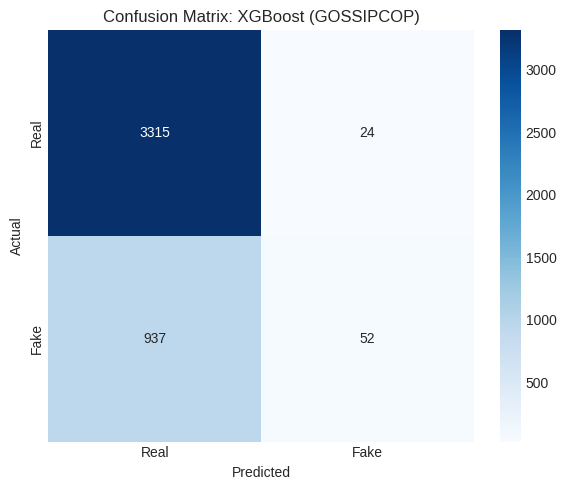


Performance Summary for GOSSIPCOP:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.771488,0.000000,0.000000,0.000000,0.548927
Random Forest,0.778420,1.000000,0.030334,0.058881,0.567261
SVM (RBF Kernel),0.704945,0.243772,0.138524,0.176660,0.530889
XGBoost,0.777957,0.684211,0.052578,0.097653,0.584247


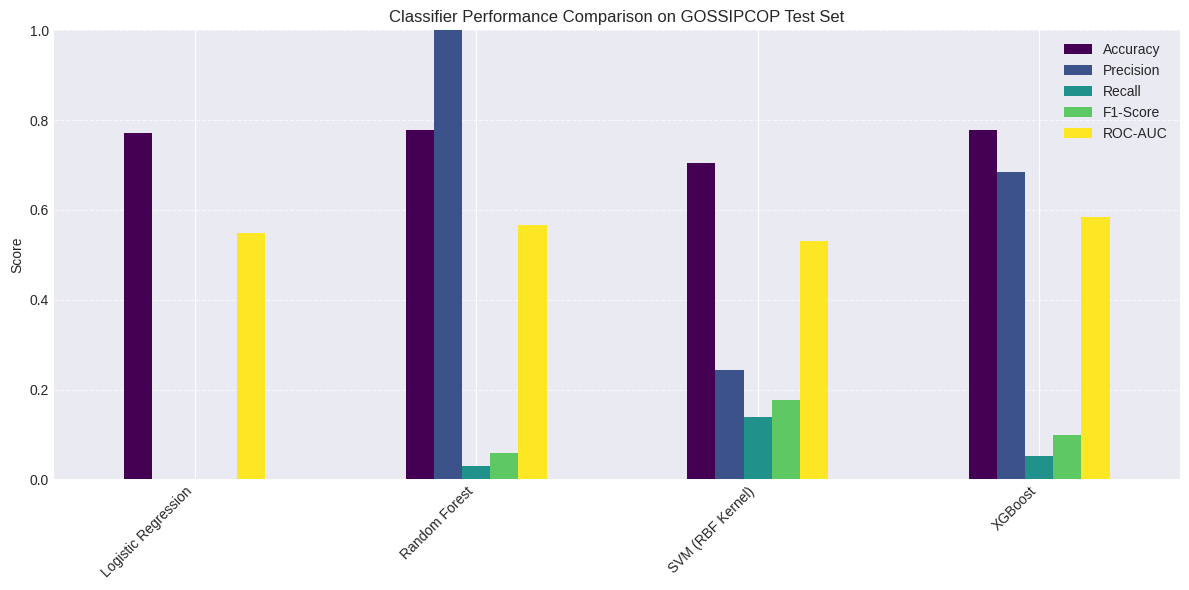


--- Preparing Data for POLITIFACT ---
  POLITIFACT Latent Vector Shape: (753, 32)
  POLITIFACT Labels Shape: (753,)
  POLITIFACT Class Distribution: {'real': np.int64(400), 'fake': np.int64(353)}
  Data Split for POLITIFACT:
    Training Samples   : 451
    Validation Samples : 151
    Testing Samples    : 151
  Feature Scaling Complete.

CLASSIFICATION FOR POLITIFACT

Training Logistic Regression for POLITIFACT...

  Logistic Regression Performance on POLITIFACT Test Set:
    Accuracy : 0.4834
    Precision: 0.4493
    Recall   : 0.4366
    F1-Score : 0.4429
    ROC-AUC  : 0.4762

  Logistic Regression Classification Report:
              precision    recall  f1-score   support

        Real       0.51      0.53      0.52        80
        Fake       0.45      0.44      0.44        71

    accuracy                           0.48       151
   macro avg       0.48      0.48      0.48       151
weighted avg       0.48      0.48      0.48       151



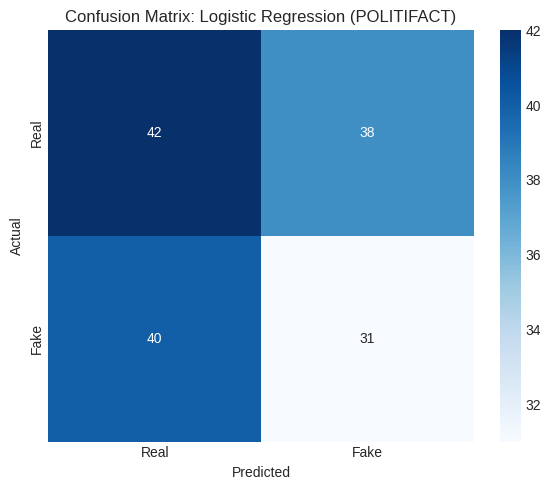


Training Random Forest for POLITIFACT...

  Random Forest Performance on POLITIFACT Test Set:
    Accuracy : 0.4967
    Precision: 0.4528
    Recall   : 0.3380
    F1-Score : 0.3871
    ROC-AUC  : 0.4761

  Random Forest Classification Report:
              precision    recall  f1-score   support

        Real       0.52      0.64      0.57        80
        Fake       0.45      0.34      0.39        71

    accuracy                           0.50       151
   macro avg       0.49      0.49      0.48       151
weighted avg       0.49      0.50      0.49       151



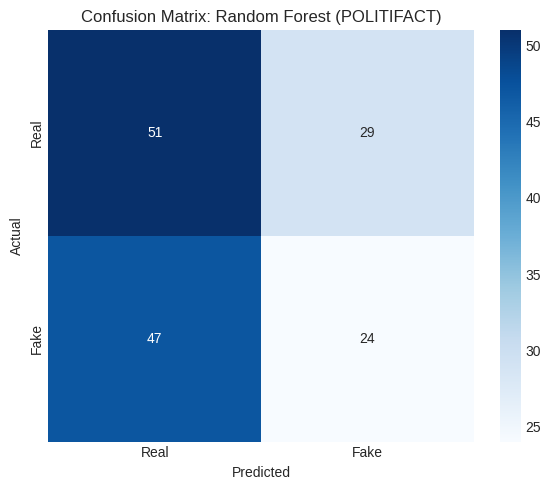


Training SVM (RBF Kernel) for POLITIFACT...

  SVM (RBF Kernel) Performance on POLITIFACT Test Set:
    Accuracy : 0.5364
    Precision: 0.5067
    Recall   : 0.5352
    F1-Score : 0.5205
    ROC-AUC  : 0.5120

  SVM (RBF Kernel) Classification Report:
              precision    recall  f1-score   support

        Real       0.57      0.54      0.55        80
        Fake       0.51      0.54      0.52        71

    accuracy                           0.54       151
   macro avg       0.54      0.54      0.54       151
weighted avg       0.54      0.54      0.54       151



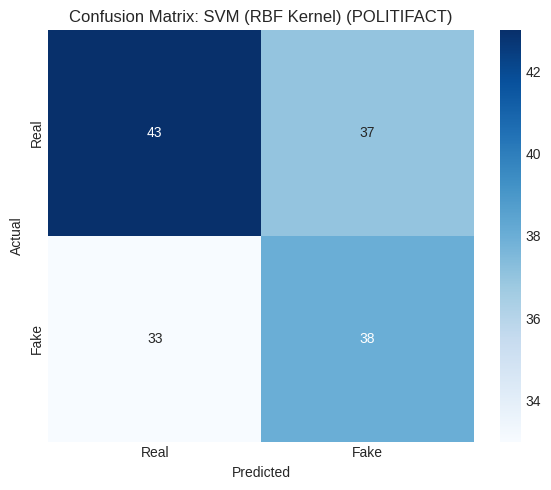


Training XGBoost for POLITIFACT...

  XGBoost Performance on POLITIFACT Test Set:
    Accuracy : 0.5298
    Precision: 0.5000
    Recall   : 0.4366
    F1-Score : 0.4662
    ROC-AUC  : 0.5004

  XGBoost Classification Report:
              precision    recall  f1-score   support

        Real       0.55      0.61      0.58        80
        Fake       0.50      0.44      0.47        71

    accuracy                           0.53       151
   macro avg       0.53      0.52      0.52       151
weighted avg       0.53      0.53      0.53       151



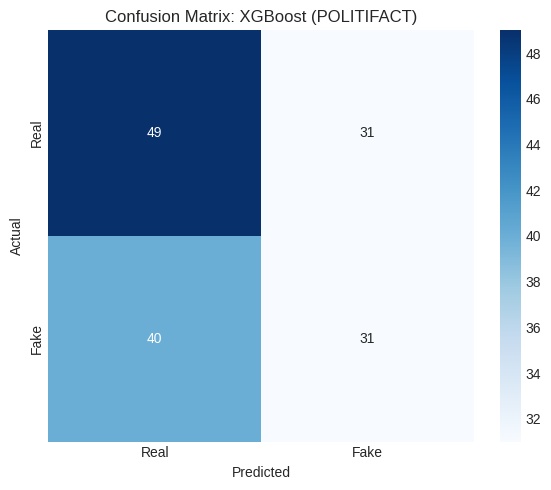


Performance Summary for POLITIFACT:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.483444,0.449275,0.436620,0.442857,0.476232
Random Forest,0.496689,0.452830,0.338028,0.387097,0.476056
SVM (RBF Kernel),0.536424,0.506667,0.535211,0.520548,0.511972
XGBoost,0.529801,0.500000,0.436620,0.466165,0.500352


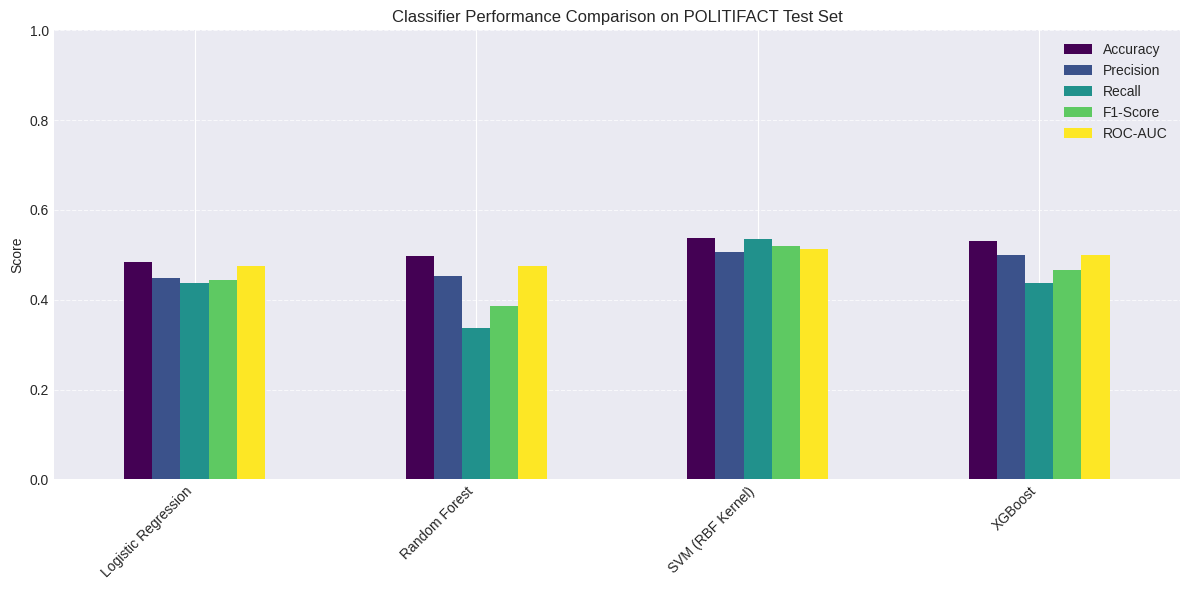


FINAL CROSS-PLATFORM COMPARISON

Overall Performance Summary (F1-Score for 'Fake' class):


,Platform,Classifier,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gossipcop,Logistic Regression,0.771488,0.000000,0.000000,0.000000,0.548927
1,Gossipcop,Random Forest,0.778420,1.000000,0.030334,0.058881,0.567261
2,Gossipcop,SVM (RBF Kernel),0.704945,0.243772,0.138524,0.176660,0.530889
3,Gossipcop,XGBoost,0.777957,0.684211,0.052578,0.097653,0.584247
4,Politifact,Logistic Regression,0.483444,0.449275,0.436620,0.442857,0.476232
5,Politifact,Random Forest,0.496689,0.452830,0.338028,0.387097,0.476056
6,Politifact,SVM (RBF Kernel),0.536424,0.506667,0.535211,0.520548,0.511972
7,Politifact,XGBoost,0.529801,0.500000,0.436620,0.466165,0.500352



Best Performing Combination (based on F1-Score for 'Fake' class):
  Platform  : Politifact
  Classifier: SVM (RBF Kernel)
  F1-Score  : 0.5205
  Accuracy  : 0.5364

------------------------------
CLASS IMBALANCE ANALYSIS
------------------------------

GOSSIPCOP Class Distribution:
  Real: 16693 (77.14%)
  Fake: 4946 (22.86%)

POLITIFACT Class Distribution:
  Real: 400 (53.12%)
  Fake: 353 (46.88%)

------------------------------
DISCUSSION ON PERFORMANCE DIFFERENCES
------------------------------
Potential reasons for performance differences observed between platforms (GossipCop vs. Politifact) and across classifiers:
  - **Nature of Fake News Content**: The characteristics of fake news (e.g., writing style, sensationalism, image manipulation tactics) might differ significantly between platforms, making it easier or harder for the MVAE to learn discriminative latent features for one over the other.
  - **Class Imbalance Severity**: While both datasets likely suffer from imbalance, th

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore") # Suppress warnings for cleaner output

# Ensure global variables are accessible. 'vae_latent_vectors' and 'df'
# are assumed to be available from previous cells in the notebook.

# ============================================================
# 1. DATA PREPARATION FUNCTION
# ============================================================
def prepare_data_for_platform(full_df, full_latent_vectors, platform_name, random_seed=42):
    """
    Filters the dataset for a specific platform, maps labels, and performs
    stratified train/validation/test split with feature scaling.

    Args:
        full_df (pd.DataFrame): The complete DataFrame containing 'source' and 'label'.
        full_latent_vectors (np.ndarray): The complete array of VAE latent vectors.
        platform_name (str): The name of the platform to filter ('gossipcop' or 'politifact').
        random_seed (int): Random seed for reproducibility.

    Returns:
        tuple: X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test,
               X_train_raw, X_val_raw, X_test_raw, scaler (for non-scaled predictions if needed)
               Returns None for all if data preparation is not possible (e.g., single class).
    """
    print(f"\n--- Preparing Data for {platform_name.upper()} ---")

    # Filter data for the specific platform
    platform_indices = full_df[full_df['source'] == platform_name].index
    X_platform = full_latent_vectors[platform_indices]
    y_platform = full_df.loc[platform_indices, 'label'].map({'real': 0, 'fake': 1}).values

    print(f"  {platform_name.upper()} Latent Vector Shape: {X_platform.shape}")
    print(f"  {platform_name.upper()} Labels Shape: {y_platform.shape}")

    unique_labels, label_counts = np.unique(y_platform, return_counts=True)
    label_distribution = dict(zip(['real' if l == 0 else 'fake' for l in unique_labels], label_counts))
    print(f"  {platform_name.upper()} Class Distribution: {label_distribution}")

    # Check for single-class data, which prevents stratified splitting and ROC-AUC
    if len(unique_labels) < 2:
        print(f"  Warning: Only one class ('{'real' if unique_labels[0]==0 else 'fake'}') present in {platform_name} data.")
        print(f"  Cannot perform stratified split or meaningful classification for {platform_name.upper()}. Skipping.")
        return None, None, None, None, None, None, None, None, None, None

    # Train / Validation / Test Split (60/20/20) with stratification
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X_platform, y_platform, test_size=0.20, random_state=random_seed, stratify=y_platform
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=0.25, random_state=random_seed, stratify=y_train_val
    )

    print(f"  Data Split for {platform_name.upper()}:")
    print(f"    Training Samples   : {X_train.shape[0]}")
    print(f"    Validation Samples : {X_val.shape[0]}")
    print(f"    Testing Samples    : {X_test.shape[0]}")

    # Feature Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    print("  Feature Scaling Complete.")

    return X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test, \
           X_train, X_val, X_test, scaler

# ============================================================
# 2. CLASSIFICATION AND EVALUATION FUNCTION
# ============================================================
def train_evaluate_classifiers(platform_name, X_train_scaled, X_val_scaled, X_test_scaled,
                               y_train, y_val, y_test, X_train_raw, X_val_raw, X_test_raw):
    """
    Trains and evaluates multiple classifiers for a given platform.
    Generates classification reports, confusion matrices, and performance plots.

    Args:
        platform_name (str): Name of the platform (for logging).
        X_train_scaled, X_val_scaled, X_test_scaled (np.ndarray): Scaled feature sets.
        y_train, y_val, y_test (np.ndarray): Label sets.
        X_train_raw, X_val_raw, X_test_raw (np.ndarray): Raw (unscaled) feature sets for tree-based models.

    Returns:
        pd.DataFrame: DataFrame containing performance metrics for all classifiers on this platform.
    """
    print(f"\n" + "=" * 60)
    print(f"CLASSIFICATION FOR {platform_name.upper()}")
    print("=" * 60)

    classifiers = {
        "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000, C=1.0, solver='liblinear'),
        "Random Forest": RandomForestClassifier(random_state=42, n_estimators=200, max_depth=None),
        "SVM (RBF Kernel)": SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42),
        "XGBoost": XGBClassifier(random_state=42, n_estimators=200, max_depth=6, learning_rate=0.1,
                                 subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', use_label_encoder=False)
    }

    platform_results = {}

    for name, model in classifiers.items():
        print(f"\nTraining {name} for {platform_name.upper()}...")

        # Use raw data for tree-based models, scaled data for others
        if name in ["Random Forest", "XGBoost"]:
            model.fit(X_train_raw, y_train)
            y_pred = model.predict(X_test_raw)
            if hasattr(model, "predict_proba"):
                y_pred_proba = model.predict_proba(X_test_raw)[:, 1]
            else:
                y_pred_proba = np.array([0.5] * len(y_test)) # Default if no proba, for ROC-AUC to handle
        else:
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            if hasattr(model, "predict_proba"):
                y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
            else:
                y_pred_proba = np.array([0.5] * len(y_test)) # Default if no proba

        # Metrics calculation (F1-score, Precision, Recall use 'binary' average by default
        # for binary classification, which is appropriate for the 'Fake' class).
        # `zero_division=0` handles cases where a class might not be predicted at all.
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        # ROC-AUC requires probabilities and at least two unique classes in y_test
        roc_auc = 0.0
        if len(np.unique(y_test)) > 1 and hasattr(model, "predict_proba"):
             # roc_auc_score fails if only one class is present in true labels, even if y_pred_proba varies
             try:
                 roc_auc = roc_auc_score(y_test, y_pred_proba)
             except ValueError: # Catch cases where true labels are constant
                 roc_auc = 0.0

        platform_results[name] = {
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1,
            "ROC-AUC": roc_auc
        }

        # 8. Clearly print results
        print(f"\n  {name} Performance on {platform_name.upper()} Test Set:")
        print(f"    Accuracy : {accuracy:.4f}")
        print(f"    Precision: {precision:.4f}")
        print(f"    Recall   : {recall:.4f}")
        print(f"    F1-Score : {f1:.4f}")
        print(f"    ROC-AUC  : {roc_auc:.4f}")

        # 7. Generate classification report
        print(f"\n  {name} Classification Report:")
        print(classification_report(y_test, y_pred, target_names=['Real', 'Fake'], zero_division=0))

        # 7. Generate confusion matrix heatmap
        fig, ax = plt.subplots(figsize=(6, 5))
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
        ax.set_title(f'Confusion Matrix: {name} ({platform_name.upper()})')
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        plt.tight_layout()
        plt.show()

    metrics_df = pd.DataFrame(platform_results).T
    print(f"\nPerformance Summary for {platform_name.upper()}:")
    display(metrics_df)

    # 7. Generate accuracy comparison graphs
    metrics_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].plot(
        kind='bar', figsize=(12, 6), colormap='viridis'
    )
    plt.title(f"Classifier Performance Comparison on {platform_name.upper()} Test Set")
    plt.ylabel("Score")
    plt.ylim(0, 1) # Metrics are between 0 and 1
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    return metrics_df

# ============================================================
# 3. MAIN EXECUTION FLOW
# ============================================================

# Load the global 'df' and 'vae_latent_vectors' from previous cells
if 'vae_latent_vectors' not in locals() or 'df' not in locals():
    print("Error: 'vae_latent_vectors' or 'df' not found. Please ensure all previous cells are executed.")
else:
    all_platform_results = {}
    platforms = ['gossipcop', 'politifact'] # Automatically identify platforms

    for platform in platforms:
        X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test, \
        X_train_raw, X_val_raw, X_test_raw, scaler = prepare_data_for_platform(
            df, vae_latent_vectors, platform
        )

        # Proceed with classification only if data preparation was successful (i.e., not a single-class dataset)
        if X_train_scaled is not None:
            platform_metrics_df = train_evaluate_classifiers(
                platform, X_train_scaled, X_val_scaled, X_test_scaled,
                y_train, y_val, y_test, X_train_raw, X_val_raw, X_test_raw
            )
            all_platform_results[platform] = platform_metrics_df
        else:
            print(f"Classification skipped for {platform.upper()} due to data issues.")

    # ============================================================
    # 4. FINAL CROSS-PLATFORM COMPARISON AND SUMMARY
    # ============================================================
    print("\n" + "=" * 60)
    print("FINAL CROSS-PLATFORM COMPARISON")
    print("=" * 60)

    if not all_platform_results:
        print("No results to compare across platforms.")
    else:
        comparison_data = []
        for platform, metrics_df in all_platform_results.items():
            for classifier, row in metrics_df.iterrows():
                comparison_data.append({
                    "Platform": platform.capitalize(),
                    "Classifier": classifier,
                    "Accuracy": row["Accuracy"],
                    "Precision": row["Precision"],
                    "Recall": row["Recall"],
                    "F1-Score": row["F1-Score"],
                    "ROC-AUC": row["ROC-AUC"]
                })
        final_comparison_df = pd.DataFrame(comparison_data)

        print("\nOverall Performance Summary (F1-Score for 'Fake' class):")
        display(final_comparison_df)

        # 9. Identify best performing dataset/classifier combination based on F1-Score
        if not final_comparison_df.empty:
            best_row = final_comparison_df.loc[final_comparison_df['F1-Score'].idxmax()]
            print(f"\nBest Performing Combination (based on F1-Score for 'Fake' class):")
            print(f"  Platform  : {best_row['Platform']}")
            print(f"  Classifier: {best_row['Classifier']}")
            print(f"  F1-Score  : {best_row['F1-Score']:.4f}")
            print(f"  Accuracy  : {best_row['Accuracy']:.4f}")
        else:
            print("No successful classifications to determine the best performing combination.")

        # 9. Class Imbalance Analysis
        print("\n" + "-" * 30)
        print("CLASS IMBALANCE ANALYSIS")
        print("-" * 30)
        for platform in platforms:
            platform_df = df[df['source'] == platform]
            label_counts = platform_df['label'].value_counts()
            total_articles = len(platform_df)
            if total_articles > 0:
                print(f"\n{platform.upper()} Class Distribution:")
                print(f"  Real: {label_counts.get('real', 0)} ({label_counts.get('real', 0)/total_articles:.2%})")
                print(f"  Fake: {label_counts.get('fake', 0)} ({label_counts.get('fake', 0)/total_articles:.2%})")
            else:
                print(f"\n{platform.upper()} has no data in the original DataFrame.")

        # 9. Discussion on Performance Differences
        print("\n" + "-" * 30)
        print("DISCUSSION ON PERFORMANCE DIFFERENCES")
        print("-" * 30)
        print("Potential reasons for performance differences observed between platforms (GossipCop vs. Politifact) and across classifiers:")
        print("  - **Nature of Fake News Content**: The characteristics of fake news (e.g., writing style, sensationalism, image manipulation tactics) might differ significantly between platforms, making it easier or harder for the MVAE to learn discriminative latent features for one over the other.")
        print("  - **Class Imbalance Severity**: While both datasets likely suffer from imbalance, the degree of imbalance (ratio of real to fake news) can vary. More severe imbalance can challenge classifiers, especially simpler ones, even with stratified sampling.")
        print("  - **Dataset Size and Quality**: One platform's dataset might be larger, more diverse, or of higher quality (e.g., clearer text, more relevant images), allowing for better feature learning and model generalization.")
        print("  - **MVAE Latent Space Effectiveness**: The VAE might capture more distinct and separable latent representations for the content from one platform compared to the other. This could be due to inherent differences in the multimodal input data.")
        print("  - **Classifier Suitability**: Certain classifiers (e.g., ensemble methods like Random Forest and XGBoost) are often more robust to complex decision boundaries and class imbalances compared to linear models (Logistic Regression, linear SVM), which might struggle if the latent features aren't linearly separable.")
        print("  - **Hyperparameter Tuning**: The current hyperparameters for the classifiers are chosen for general performance. Optimal hyperparameters might vary significantly between platforms, and dedicated tuning for each could yield better results.")

        # Save results to CSV
        output_csv_path = 'cross_platform_classification_results.csv'
        final_comparison_df.to_csv(output_csv_path, index=False)
        print(f"\nDetailed cross-platform results saved to '{output_csv_path}'")

    print("\n" + "=" * 60)
    print("CROSS-PLATFORM EVALUATION COMPLETE")
    print("=" * 60)


# Cross-Platform Fake News & Trend Detection Using Multimodal Variational Autoencoder (MVAE)

## Detailed Evaluation of Classifiers on Politifact and GossipCop

Loaded VAE Latent Vectors shape: (22392, 32)
Loaded DataFrame shape: (22392, 16)

Processing Platform: POLITIFACT
  POLITIFACT Data Size: 753 samples
  POLITIFACT Class Distribution: {'Real': np.int64(400), 'Fake': np.int64(353)}
  Data Split for POLITIFACT:
    Training samples   : 451
    Validation samples : 151
    Testing samples    : 151
  Feature scaling applied to training, validation, and test sets.

  Training and evaluating Logistic Regression...
    Accuracy: 0.4834
    Fake News F1-score: 0.4429

  Training and evaluating Random Forest...
    Accuracy: 0.4967
    Fake News F1-score: 0.3871

  Training and evaluating SVM (RBF Kernel)...
    Accuracy: 0.5364
    Fake News F1-score: 0.5205

  Training and evaluating XGBoost...
    Accuracy: 0.5298
    Fake News F1-score: 0.4662

  Generating Confusion Matrix for Best 

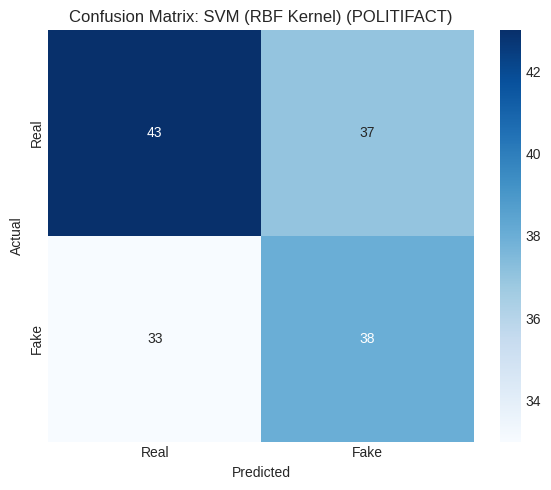


  Generating Performance Comparison Bar Chart for POLITIFACT...


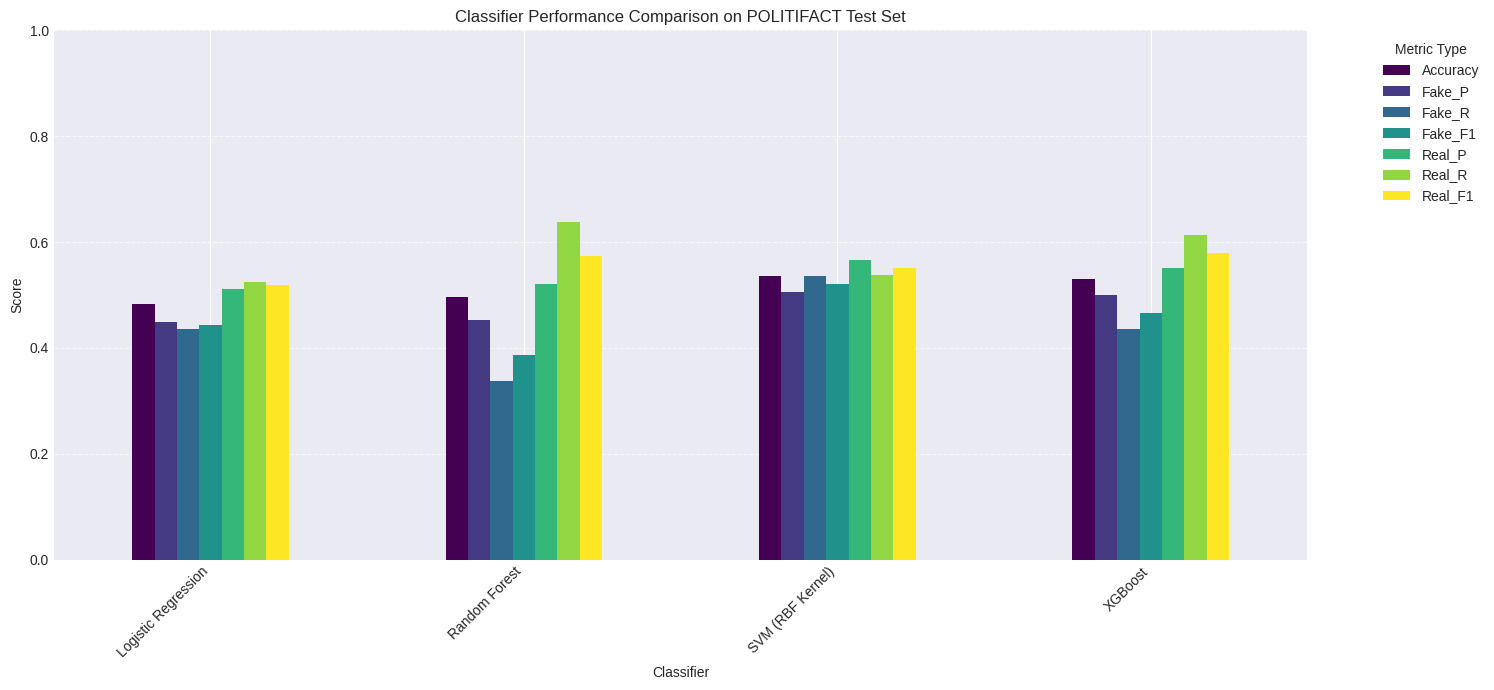


  Best model for POLITIFACT (SVM (RBF Kernel)) saved to 'best_model_politifact_mvae.joblib'
  Achieved Fake News F1-score: 0.5205

Processing Platform: GOSSIPCOP
  GOSSIPCOP Data Size: 21639 samples
  GOSSIPCOP Class Distribution: {'Real': np.int64(16693), 'Fake': np.int64(4946)}
  Data Split for GOSSIPCOP:
    Training samples   : 12983
    Validation samples : 4328
    Testing samples    : 4328
  Feature scaling applied to training, validation, and test sets.

  Training and evaluating Logistic Regression...
    Accuracy: 0.7715
    Fake News F1-score: 0.0000

  Training and evaluating Random Forest...
    Accuracy: 0.7784
    Fake News F1-score: 0.0589

  Training and evaluating SVM (RBF Kernel)...
    Accuracy: 0.7049
    Fake News F1-score: 0.1767

  Training and evaluating XGBoost...
    Accuracy: 0.7780
    Fake News F1-score: 0.0977

  Generating Confusion Matrix for Best Model (SVM (RBF Kernel)) on GOSSIPCOP...


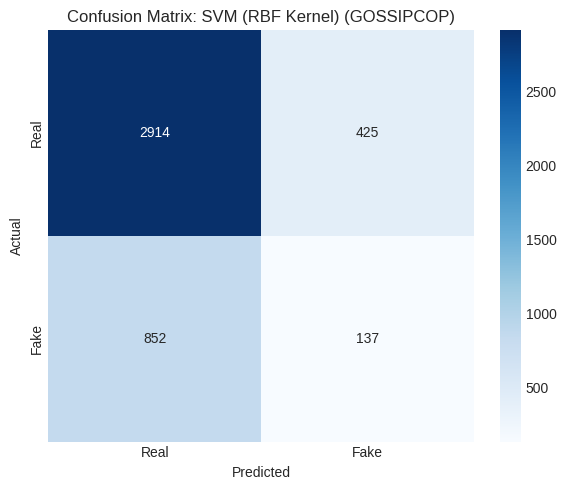


  Generating Performance Comparison Bar Chart for GOSSIPCOP...


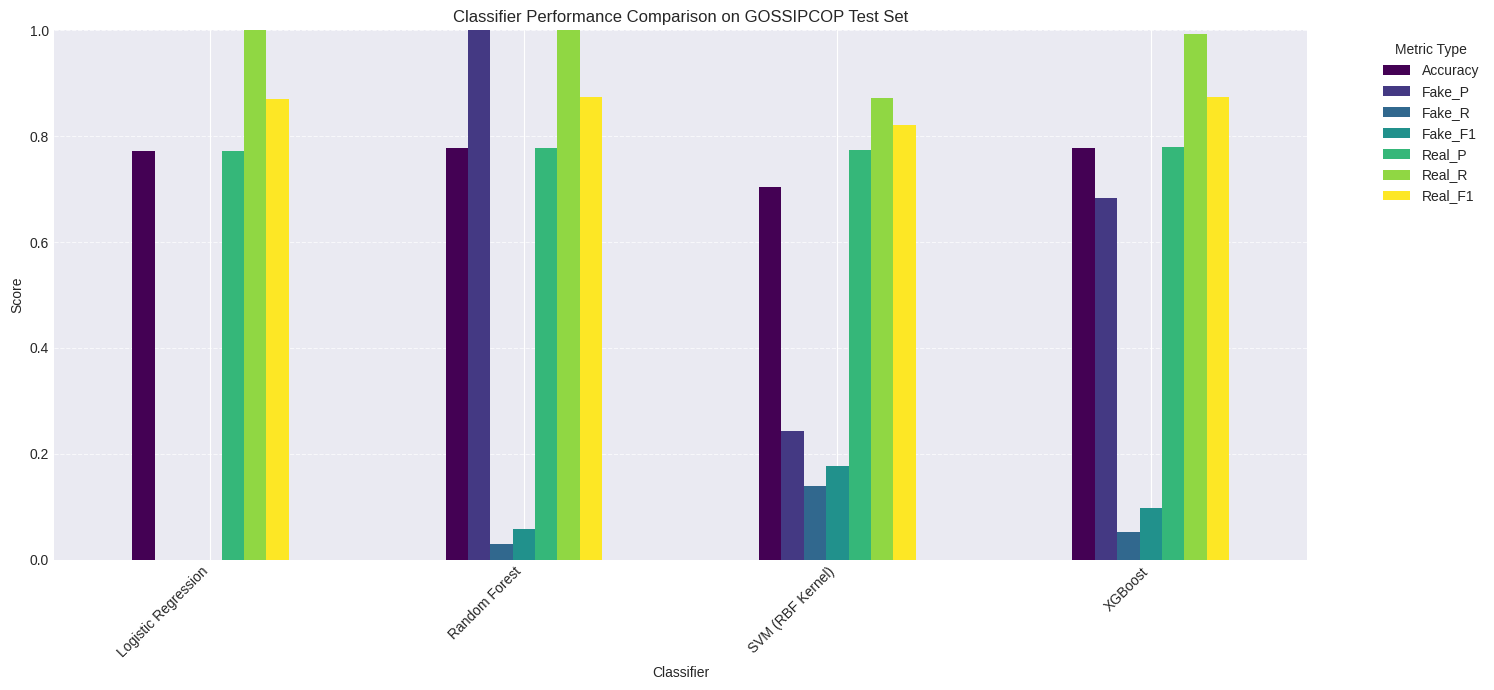


  Best model for GOSSIPCOP (SVM (RBF Kernel)) saved to 'best_model_gossipcop_mvae.joblib'
  Achieved Fake News F1-score: 0.1767


In [29]:
# ============================================================
# COMPLETE CROSS-PLATFORM EVALUATION FOR FAKE NEWS DETECTION
# USING MVAE LATENT VECTORS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Suppress warnings for cleaner output during execution
warnings.filterwarnings("ignore")

# Set random seed for reproducibility across all splits and model initializations
RANDOM_STATE = 42

print("""# Cross-Platform Fake News & Trend Detection Using Multimodal Variational Autoencoder (MVAE)

## Detailed Evaluation of Classifiers on Politifact and GossipCop
""")

# --- Robustly ensure 'vae_latent_vectors' and 'df' are available ---
# The error indicates these are not found in locals(), despite being in kernel state.
# Explicitly re-loading vae_latent_vectors and checking df to ensure availability.

# Check for df (which is usually persistent)
if 'df' not in locals():
    raise ValueError(
        "Error: DataFrame 'df' not found. "
        "Please ensure data loading and cleaning cells are executed."
    )

# Attempt to load vae_latent_vectors if not in locals()
if 'vae_latent_vectors' not in locals():
    print("Warning: 'vae_latent_vectors' not found in local scope. Attempting to reload from Google Drive...")
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=True) # Force remount to ensure access
        drive_path = '/content/drive/MyDrive/Colab_Checkpoints' # Re-define path for robustness
        latent_save_path = os.path.join(drive_path, "vae_latent_vectors.npy")
        vae_latent_vectors = np.load(latent_save_path)
        print(f"Successfully re-loaded vae_latent_vectors from {latent_save_path}")
    except Exception as e:
        raise ValueError(
            f"Error: 'vae_latent_vectors' not found and failed to reload from Drive. "
            f"Please ensure VAE training cell was executed successfully and saved latent vectors. Details: {e}"
        )

print(f"Loaded VAE Latent Vectors shape: {vae_latent_vectors.shape}")
print(f"Loaded DataFrame shape: {df.shape}")

# --- Define Classifiers for comparison ---
CLASSIFIERS = {
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, C=1.0, solver='liblinear'),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200, max_depth=None, n_jobs=-1), # n_jobs=-1 for parallel processing
    "SVM (RBF Kernel)": SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, n_estimators=200, max_depth=6, learning_rate=0.1,
                             subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', use_label_encoder=False,
                             n_jobs=-1) # n_jobs=-1 for parallel processing
}

# ============================================================
# HELPER FUNCTION: Evaluate a single model and extract per-class metrics
# ============================================================
def evaluate_model_per_class(model, X_test, y_test, target_names=['Real', 'Fake']):
    """
    Evaluates a trained model and returns metrics for 'fake' and 'real' classes separately.
    """
    y_pred = model.predict(X_test)

    # Overall Accuracy (global metric)
    overall_accuracy = accuracy_score(y_test, y_pred)

    # Classification report to get per-class metrics
    report = classification_report(y_test, y_pred, target_names=target_names, output_dict=True, zero_division=0)

    # Extract metrics for 'Fake' and 'Real' classes
    fake_metrics = {
        'ACC': overall_accuracy, # Using overall accuracy as per the table structure interpretation
        'P': report['Fake']['precision'],
        'R': report['Fake']['recall'],
        'F1': report['Fake']['f1-score']
    }
    real_metrics = {
        'ACC': overall_accuracy, # Using overall accuracy as per the table structure interpretation
        'P': report['Real']['precision'],
        'R': report['Real']['recall'],
        'F1': report['Real']['f1-score']
    }

    return overall_accuracy, fake_metrics, real_metrics, report['Fake']['f1-score'] # Return fake F1 for best model selection

# ============================================================
# HELPER FUNCTION: Process a single platform (Politifact or GossipCop)
# ============================================================
def process_platform(platform_name, full_df, full_latent_vectors):
    """
    Filters data for a specific platform, trains and evaluates classifiers,
    generates plots, and returns the best classifier's metrics for the platform.
    """
    print(f"\n" + "=" * 80)
    print(f"Processing Platform: {platform_name.upper()}")
    print("=" * 80)

    # 1. Filter data for the specific platform
    platform_indices = full_df[full_df['source'] == platform_name].index
    X_platform = full_latent_vectors[platform_indices]
    y_platform = full_df.loc[platform_indices, 'label'].map({'real': 0, 'fake': 1}).values

    print(f"  {platform_name.upper()} Data Size: {X_platform.shape[0]} samples")
    unique_labels, label_counts = np.unique(y_platform, return_counts=True)
    label_distribution = dict(zip(['Real' if l == 0 else 'Fake' for l in unique_labels], label_counts))
    print(f"  {platform_name.upper()} Class Distribution: {label_distribution}")

    # Handle cases with only one class (prevents stratified split errors)
    if len(unique_labels) < 2:
        print(f"  Warning: Only one class detected in {platform_name.upper()}. Skipping classification for this platform.")
        return None, None, None, None, None # Return Nones for metrics, best model, etc.

    # 2. Stratified Train/Validation/Test Split (60/20/20)
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X_platform, y_platform, test_size=0.20, random_state=RANDOM_STATE, stratify=y_platform
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=0.25, random_state=RANDOM_STATE, stratify=y_train_val
    )

    print(f"  Data Split for {platform_name.upper()}:")
    print(f"    Training samples   : {X_train.shape[0]}")
    print(f"    Validation samples : {X_val.shape[0]}")
    print(f"    Testing samples    : {X_test.shape[0]}")

    # 3. Feature Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    print("  Feature scaling applied to training, validation, and test sets.")

    platform_classifier_results = [] # To store results for all classifiers on this platform
    best_f1_fake_for_platform = -1
    best_model_for_platform = None
    best_model_name_for_platform = ""
    best_metrics_for_platform = None

    # 4. Train and Evaluate Classifiers
    for clf_name, clf_model in CLASSIFIERS.items():
        print(f"\n  Training and evaluating {clf_name}...")

        # Use scaled data for non-tree models, raw data for tree-based models
        current_X_train = X_train_scaled if clf_name not in ["Random Forest", "XGBoost"] else X_train
        current_X_test = X_test_scaled if clf_name not in ["Random Forest", "XGBoost"] else X_test

        clf_model.fit(current_X_train, y_train)

        # Evaluate model and get per-class metrics
        overall_acc, fake_metrics, real_metrics, current_f1_fake = \
            evaluate_model_per_class(clf_model, current_X_test, y_test)

        # Store all classifier results for the bar chart
        platform_classifier_results.append({
            'Classifier': clf_name,
            'Accuracy': overall_acc,
            'Fake_P': fake_metrics['P'],
            'Fake_R': fake_metrics['R'],
            'Fake_F1': fake_metrics['F1'],
            'Real_P': real_metrics['P'],
            'Real_R': real_metrics['R'],
            'Real_F1': real_metrics['F1']
        })

        # Keep track of the best model for this platform based on F1-score for 'Fake' news
        if current_f1_fake > best_f1_fake_for_platform:
            best_f1_fake_for_platform = current_f1_fake
            best_model_for_platform = clf_model
            best_model_name_for_platform = clf_name
            best_metrics_for_platform = {
                'Platform': platform_name.capitalize(),
                'Model': "MVAE" + " (" + clf_name + ")", # Format for the final table
                'Fake News ACC': fake_metrics['ACC'],
                'Fake News P': fake_metrics['P'],
                'Fake News R': fake_metrics['R'],
                'Fake News F1': fake_metrics['F1'],
                'Real News ACC': real_metrics['ACC'],
                'Real News P': real_metrics['P'],
                'Real News R': real_metrics['R'],
                'Real News F1': real_metrics['F1']
            }

        print(f"    Accuracy: {overall_acc:.4f}")
        print(f"    Fake News F1-score: {fake_metrics['F1']:.4f}")

    # 5. Generate Confusion Matrix for the BEST model on this platform
    if best_model_for_platform:
        print(f"\n  Generating Confusion Matrix for Best Model ({best_model_name_for_platform}) on {platform_name.upper()}...")
        best_X_test = X_test_scaled if best_model_name_for_platform not in ["Random Forest", "XGBoost"] else X_test
        y_pred_best = best_model_for_platform.predict(best_X_test)

        fig, ax = plt.subplots(figsize=(6, 5))
        cm = confusion_matrix(y_test, y_pred_best)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
        ax.set_title(f'Confusion Matrix: {best_model_name_for_platform} ({platform_name.upper()})')
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        plt.tight_layout()
        plt.show()

    # 6. Generate Bar Chart Comparison for ALL classifiers on this platform
    print(f"\n  Generating Performance Comparison Bar Chart for {platform_name.upper()}...")
    metrics_df_platform = pd.DataFrame(platform_classifier_results).set_index('Classifier')
    metrics_df_platform[['Accuracy', 'Fake_P', 'Fake_R', 'Fake_F1', 'Real_P', 'Real_R', 'Real_F1']].plot(
        kind='bar', figsize=(15, 7), colormap='viridis'
    )
    plt.title(f"Classifier Performance Comparison on {platform_name.upper()} Test Set")
    plt.ylabel("Score")
    plt.ylim(0, 1) # Metrics are between 0 and 1
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title='Metric Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # 7. Save the Best Model for this platform
    if best_model_for_platform:
        model_filename = f'best_model_{platform_name}_mvae.joblib'
        joblib.dump(best_model_for_platform, model_filename)
        print(f"\n  Best model for {platform_name.upper()} ({best_model_name_for_platform}) saved to '{model_filename}'")
        print(f"  Achieved Fake News F1-score: {best_f1_fake_for_platform:.4f}")

    return best_metrics_for_platform, best_model_name_for_platform, best_f1_fake_for_platform

# ============================================================
# MAIN EXECUTION FLOW
# ============================================================

all_platform_results = []
overall_best_f1 = -1
overall_best_model_info = None

# Process each dataset (Politifact and GossipCop)
platforms = ['politifact', 'gossipcop']

for platform in platforms:
    metrics, best_model_name, best_f1_fake = process_platform(platform, df, vae_latent_vectors)
    if metrics is not None:
        all_platform_results.append(metrics)
        # Track overall best model across all platforms
        if best_f1_fake > overall_best_f1:
            overall_best_f1 = best_f1_fake
            overall_best_model_info = {
                'Platform': platform.capitalize(),
                'Classifier': best_model_name,
                'F1-Score (Fake)': best_f1_fake,
                'Accuracy': metrics['Fake News ACC'] # Overall Accuracy of the best model
            }

